# Deep Learning for Image Inpainting

## Introduction

Image inpainting reconstructs missing image regions from the visible surrounding content. This project compares a lightweight **U-Net**, a lightweight **Vision Transformer (ViT)**, and a **weighted U-Net–ViT ensemble** on the Oxford-IIIT Pet Dataset.

The study includes an initial ViT experiment and a targeted architecture revision. Models and ensemble weights were selected using validation data, then frozen for final test evaluation across different rectangular mask sizes and positions. Quantitative metrics, reconstruction examples, and difficult cases characterize both performance and limitations.

## Experimental Setup

| Component | Configuration |
|---|---|
| Dataset and preprocessing | Oxford-IIIT Pet; 128 x 128 RGB images; pixel range [0, 1] |
| Data split | Official trainval split divided 80%/20% into training/validation; official test split reserved for final reporting |
| Reproducibility and batching | Seed 42; batch size 32; 2 data-loader workers |
| Training masks | 32 x 32 central rectangles; missing pixels filled with 0 |
| Test masks | 24 x 24, 32 x 32, and 48 x 48; central and deterministic random positions |
| U-Net | Encoder channels 32, 64, 128; bottleneck 256; decoder 128, 64, 32; concatenated skip connections |
| Initial ViT | 16 x 16 patches; 64 tokens; linear patch reconstruction head |
| Improved ViT | 8 x 8 patches; 256 tokens; embedding dimension 128; 4 heads; 4 encoder layers; convolutional upsampling decoder |
| Training objective | MSE averaged over the missing region and RGB channels |
| Optimizers | U-Net and initial ViT: Adam, learning rate 0.001; improved ViT: AdamW, learning rate 0.001, weight decay 0.01 |
| Training budget and selection | 15 epochs per model; checkpoint selected by lowest validation masked-region MSE |
| Metrics | Whole-image MSE, PSNR, SSIM; masked-region MSE and PSNR; per-image averaging; data range 1.0 |
| Ensemble | 0.75 U-Net + 0.25 improved ViT; alpha selected using validation and frozen before test evaluation |

All models reconstruct only the missing region for evaluation; visible pixels are preserved. Validation supports model and ensemble selection, while the official test split provides final reporting.

In [ ]:
import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms

SEED = 42
IMAGE_SIZE = 128
BATCH_SIZE = 32
NUM_WORKERS = 2
TRAIN_FRACTION = 0.8
# Download into Colab's temporary runtime storage when this cell is run there.
DATA_ROOT = Path('/content/data') if Path('/content').is_dir() else Path('data')

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
print(f'Dataset location: {DATA_ROOT.resolve()}')

## Dataset and Preprocessing

Oxford-IIIT Pet contains photographs of cats and dogs from 37 pet categories. The photographs are used as reconstruction targets; category labels are not used for inpainting.

The official **trainval** split is partitioned deterministically into **80% training and 20% validation** using seed 42. All models use these same subsets. The **official test split** is excluded from training and model selection and used only for final evaluation.

Images are loaded as RGB, resized to **128 x 128**, and converted to floating-point tensors in **[0, 1]**, without ImageNet mean/std normalization. Training batches are shuffled; validation and test batches retain a fixed order.

In [ ]:
image_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
])

trainval_dataset = datasets.OxfordIIITPet(
    root=DATA_ROOT,
    split='trainval',
    target_types='category',
    transform=image_transform,
    download=True,
)
test_dataset = datasets.OxfordIIITPet(
    root=DATA_ROOT,
    split='test',
    target_types='category',
    transform=image_transform,
    download=True,
)

train_size = int(TRAIN_FRACTION * len(trainval_dataset))
val_size = len(trainval_dataset) - train_size
train_dataset, val_dataset = random_split(
    trainval_dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(SEED),
)

In [ ]:
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    generator=torch.Generator().manual_seed(SEED),
)
val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
)
test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
)

In [ ]:
print(f'Official trainval: {len(trainval_dataset):,}')
print(f'Training:         {len(train_dataset):,}')
print(f'Validation:       {len(val_dataset):,}')
print(f'Official test:     {len(test_dataset):,}')

# Check that training and validation partition trainval without overlap.
train_indices = set(train_dataset.indices)
val_indices = set(val_dataset.indices)
assert len(train_indices) == train_size > 0
assert len(val_indices) == val_size > 0
assert train_indices.isdisjoint(val_indices)
assert train_indices | val_indices == set(range(len(trainval_dataset)))
assert test_dataset is not trainval_dataset
assert len(test_dataset) > 0

# Verify that the same seed reproduces exactly the same split.
expected_indices = torch.randperm(
    len(trainval_dataset), generator=torch.Generator().manual_seed(SEED)
).tolist()
assert train_dataset.indices == expected_indices[:train_size]
assert val_dataset.indices == expected_indices[train_size:]

# Inspect a training batch only; do not iterate over the test set.
images, _ = next(iter(train_loader))
print(f'Batch shape: {list(images.shape)}')
print(f'Pixel range: [{images.min().item():.3f}, {images.max().item():.3f}]')
assert images.shape == (min(BATCH_SIZE, train_size), 3, IMAGE_SIZE, IMAGE_SIZE)
assert images.dtype == torch.float32
assert torch.isfinite(images).all().item()
assert 0.0 <= images.min().item() <= images.max().item() <= 1.0
print('All split and training-batch sanity checks passed.')

In [ ]:
# Display eight original training images from the checked batch.
fig, axes = plt.subplots(2, 4, figsize=(10, 5))
for index, ax in enumerate(axes.flat):
    ax.imshow(images[index].permute(1, 2, 0).numpy())
    ax.set_title(f'Training image {index + 1}')
    ax.axis('off')
fig.suptitle('Original training images (128 x 128)')
plt.tight_layout()
plt.show()

## Image Masking

The **masked image is the model input**, and the **unchanged original image is the reconstruction target**. We use central or randomly positioned rectangular masks, with examples of sizes **24 x 24**, **32 x 32**, and **48 x 48**.

For each RGB image of shape `[3, H, W]`, the binary mask has shape `[1, H, W]`: **1 (True) marks missing pixels**, and **0 (False) marks visible pixels**. The same mask covers all three color channels. Missing pixels are filled with **0 (black)** in a new tensor, leaving the target unchanged. In the mask plots, white indicates the missing region.

A supplied seed reproduces the random position for the same image dimensions and mask size. The visual checks demonstrate both mask positions and all three sizes. Model training uses only 32 x 32 central masks; the other conditions measure robustness without additional training.

In [ ]:
MASK_SIZES = [(24, 24), (32, 32), (48, 48)]
MASK_FILL_VALUE = 0.0


def make_rectangular_mask(image, mask_size=(32, 32), position='central', seed=None):
    """Return a boolean [1, H, W] mask: True means a missing pixel."""
    if image.ndim != 3 or image.shape[0] != 3:
        raise ValueError('Expected an RGB image with shape [3, H, W].')
    height, width = image.shape[-2:]
    mask_height, mask_width = mask_size
    if not (0 < mask_height <= height and 0 < mask_width <= width):
        raise ValueError('Mask dimensions must be positive and fit inside the image.')

    if position == 'central':
        top = (height - mask_height) // 2
        left = (width - mask_width) // 2
    elif position == 'random':
        # A local seeded generator does not reset the global random state.
        generator = None if seed is None else torch.Generator().manual_seed(seed)
        top = torch.randint(height - mask_height + 1, (1,), generator=generator).item()
        left = torch.randint(width - mask_width + 1, (1,), generator=generator).item()
    else:
        raise ValueError("position must be 'central' or 'random'.")

    mask = torch.zeros((1, height, width), dtype=torch.bool, device=image.device)
    mask[:, top:top + mask_height, left:left + mask_width] = True
    return mask


def apply_mask(image, mask):
    """Fill the hole in a new tensor; preserve the original image."""
    return image.masked_fill(mask, MASK_FILL_VALUE)

In [ ]:
# Use only training images from Phase 1; the test set stays untouched.
originals_before_masking = images.clone()
for position in ('central', 'random'):
    for mask_size in MASK_SIZES:
        target = images[0]
        mask = make_rectangular_mask(target, mask_size, position, seed=SEED)
        masked_image = apply_mask(target, mask)

        assert mask.shape == (1, IMAGE_SIZE, IMAGE_SIZE)
        assert mask.dtype == torch.bool
        assert masked_image.shape == target.shape
        # Count spatial pixels once, not once per RGB channel.
        assert mask.sum().item() == mask_size[0] * mask_size[1]
        missing_channels = mask.expand_as(target)
        assert torch.all(masked_image[missing_channels] == MASK_FILL_VALUE).item()
        assert torch.equal(masked_image[~missing_channels], target[~missing_channels])
        assert torch.equal(images, originals_before_masking)

        if position == 'central':
            top = (IMAGE_SIZE - mask_size[0]) // 2
            left = (IMAGE_SIZE - mask_size[1]) // 2
            assert mask[:, top:top + mask_size[0], left:left + mask_size[1]].all().item()
        else:
            repeated_mask = make_rectangular_mask(target, mask_size, position, seed=SEED)
            assert torch.equal(mask, repeated_mask)

        print(f'{position:7s} {mask_size}: {mask.sum().item()} missing pixels - passed')

print('All Phase 2 sanity checks passed; original targets are unchanged.')

In [ ]:
# Two figures, each with three training images and all three mask sizes.
# Reuse the same originals across figures for a direct position comparison.
for position in ('central', 'random'):
    fig, axes = plt.subplots(3, 3, figsize=(9, 9))
    for row, mask_size in enumerate(MASK_SIZES):
        target = images[row]
        mask = make_rectangular_mask(target, mask_size, position, seed=SEED + row)
        masked_image = apply_mask(target, mask)

        axes[row, 0].imshow(target.permute(1, 2, 0).cpu().numpy())
        axes[row, 1].imshow(masked_image.permute(1, 2, 0).cpu().numpy())
        axes[row, 2].imshow(mask[0].cpu().numpy(), cmap='gray', vmin=0, vmax=1)
        axes[row, 0].set_title(f'Original (training image {row + 1})')
        axes[row, 1].set_title(f'Masked ({mask_size[0]} x {mask_size[1]})')
        axes[row, 2].set_title('Mask (white = missing)')
        for ax in axes[row]:
            ax.axis('off')

    fig.suptitle(f'{position.capitalize()} rectangular masks')
    plt.tight_layout()
    plt.show()

assert torch.equal(images, originals_before_masking)

## U-Net Architecture

U-Net reconstructs an image through an **encoder**, a **bottleneck**, and a **decoder**:

- The encoder extracts features at 128 x 128, 64 x 64, and 32 x 32 resolutions, with 32, 64, and 128 channels. Max pooling halves the spatial size between stages.
- The bottleneck uses 256 channels at 16 x 16 to represent the surrounding image context.
- The decoder upsamples back to 128 x 128 using transposed convolutions and refines features with convolution blocks.
- **Skip connections** concatenate encoder features with decoder features at matching resolutions. They give the decoder direct access to spatial details, such as edges and textures in the visible region, which helps image reconstruction and inpainting.

Each convolution block contains two 3 x 3 convolutions (padding 1), each followed by ReLU. Decoder upsampling uses 2 x 2 transposed convolutions with stride 2. A final 3 x 3 convolution maps 32 channels to 3 RGB channels; sigmoid constrains predictions to [0, 1].

The model takes only the masked RGB image and predicts a full RGB image of the same size. The initial forward-pass checks verify shapes and value ranges before training. **Untrained predictions are not experimental reconstruction results.**

In [ ]:
from torch import nn


def conv_block(in_channels, out_channels):
    """Two convolutions that preserve spatial dimensions."""
    return nn.Sequential(
        nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
        nn.ReLU(),
        nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
        nn.ReLU(),
    )


class UNet(nn.Module):
    """Small U-Net for [B, 3, 128, 128] masked RGB images."""

    def __init__(self):
        super().__init__()
        self.encoder1 = conv_block(3, 32)
        self.encoder2 = conv_block(32, 64)
        self.encoder3 = conv_block(64, 128)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.bottleneck = conv_block(128, 256)

        self.up3 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.decoder3 = conv_block(128 + 128, 128)
        self.up2 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.decoder2 = conv_block(64 + 64, 64)
        self.up1 = nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2)
        self.decoder1 = conv_block(32 + 32, 32)

        self.output_conv = nn.Conv2d(32, 3, kernel_size=3, padding=1)
        self.output_activation = nn.Sigmoid()

    def forward(self, x):
        enc1 = self.encoder1(x)                  # [B, 32, 128, 128]
        enc2 = self.encoder2(self.pool(enc1))    # [B, 64, 64, 64]
        enc3 = self.encoder3(self.pool(enc2))    # [B, 128, 32, 32]
        bottleneck = self.bottleneck(self.pool(enc3))  # [B, 256, 16, 16]

        # Concatenate along the channel dimension at matching resolutions.
        dec3 = self.decoder3(torch.cat([self.up3(bottleneck), enc3], dim=1))
        dec2 = self.decoder2(torch.cat([self.up2(dec3), enc2], dim=1))
        dec1 = self.decoder1(torch.cat([self.up1(dec2), enc1], dim=1))
        return self.output_activation(self.output_conv(dec1))

In [ ]:
# Reuse the device detected in Phase 1 under the requested uppercase name.
DEVICE = device
# Make initialization reproducible when this cell is rerun.
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

unet = UNet().to(DEVICE)
trainable_parameters = sum(p.numel() for p in unet.parameters() if p.requires_grad)
print(f'U-Net device: {DEVICE}')
print(f'Trainable parameters: {trainable_parameters:,}')

In [ ]:
# Small forward-pass example using training images and Phase 2 mask functions.
# These two masks are examples, not a choice of training-mask mixture.
unet_targets = images[:2].clone()
unet_example_masks = torch.stack([
    make_rectangular_mask(unet_targets[0], (32, 32), position='central'),
    make_rectangular_mask(unet_targets[1], (32, 32), position='random', seed=SEED),
])
unet_inputs = torch.stack([
    apply_mask(target, mask)
    for target, mask in zip(unet_targets, unet_example_masks)
]).to(DEVICE)

unet.eval()
with torch.no_grad():
    untrained_predictions = unet(unet_inputs)

assert unet_inputs.shape == (2, 3, IMAGE_SIZE, IMAGE_SIZE)
assert untrained_predictions.shape == unet_inputs.shape
assert torch.isfinite(untrained_predictions).all().item()
assert 0.0 <= untrained_predictions.min().item() <= untrained_predictions.max().item() <= 1.0
assert torch.equal(unet_targets, images[:2])

print(f'Input shape:  {list(unet_inputs.shape)}')
print(f'Output shape: {list(untrained_predictions.shape)}')
print(f'Untrained output range: [{untrained_predictions.min().item():.4f}, '
      f'{untrained_predictions.max().item():.4f}]')
print('Phase 3 forward-pass checks passed. No training has been performed.')

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(9, 6))
for row in range(2):
    axes[row, 0].imshow(unet_targets[row].permute(1, 2, 0).cpu().numpy())
    axes[row, 1].imshow(unet_inputs[row].permute(1, 2, 0).cpu().numpy())
    axes[row, 2].imshow(untrained_predictions[row].permute(1, 2, 0).cpu().numpy())
    for ax, title in zip(axes[row], ('Original target', 'Masked input', 'UNTRAINED prediction')):
        ax.set_title(title)
        ax.axis('off')
fig.suptitle('Randomly initialized U-Net: sanity check only, not experimental results')
plt.tight_layout()
plt.show()

## U-Net Training and Validation

The main training task uses **32 x 32 central masks** on 128 x 128 images. The masked image is the input and the original image is the reconstruction target. Training uses only the training subset; validation monitors learning and selects the checkpoint with the lowest validation loss. The test split is excluded from this process.

The objective is **masked-region MSE**: squared error averaged over missing pixels and all three RGB channels. This prevents the larger visible region from dominating the loss. Evaluation and visualization preserve visible input pixels and insert model predictions only inside the hole.

U-Net uses Adam with learning rate 0.001 for 15 epochs. The best-validation weights are stored as an independent in-memory copy and restored for evaluation.

In [ ]:
from skimage.metrics import structural_similarity

TRAIN_MASK_SIZE = 32
UNET_LEARNING_RATE = 1e-3
UNET_EPOCHS = 15

# Reuse the existing loaders (and their BATCH_SIZE), splits, and DEVICE.
print(f'Device: {DEVICE} | Batch size: {BATCH_SIZE}')
print(f'Central mask: {TRAIN_MASK_SIZE} x {TRAIN_MASK_SIZE}')
print(f'Adam learning rate: {UNET_LEARNING_RATE} | Epochs: {UNET_EPOCHS}')

In [ ]:
def make_training_inputs(targets):
    """Apply the same central mask to every image in a batch."""
    # Reuse Phase 2; a central mask is identical for all images of this size.
    mask = make_rectangular_mask(
        targets[0], (TRAIN_MASK_SIZE, TRAIN_MASK_SIZE), position='central'
    ).unsqueeze(0)  # [1, 1, H, W]
    masks = mask.expand(targets.shape[0], -1, -1, -1)  # [B, 1, H, W]
    return apply_mask(targets, masks), masks


def masked_mse_loss(predictions, targets, masks):
    """Average squared error over missing pixels, including RGB channels."""
    missing_channels = masks.expand_as(predictions)
    squared_error = (predictions - targets).square()
    # Expanding the mask counts each missing pixel once per color channel.
    return (squared_error * missing_channels).sum() / missing_channels.sum()


def reconstruct_images(masked_inputs, predictions, masks):
    """Keep visible input pixels; use predictions only inside the hole."""
    return torch.where(masks, predictions, masked_inputs)


def reconstruction_metrics(target, reconstruction, mask):
    """Phase 4 metric conventions, shared by U-Net and ViT (one CHW image)."""
    target_array = target.permute(1, 2, 0).cpu().numpy().astype(np.float64)
    reconstruction_array = reconstruction.permute(1, 2, 0).cpu().numpy().astype(np.float64)
    squared_error = (reconstruction_array - target_array) ** 2
    whole_mse = float(squared_error.mean())
    missing_pixels = mask[0].cpu().numpy()
    hole_mse = float(squared_error[missing_pixels].mean())
    ssim = structural_similarity(
        target_array, reconstruction_array, data_range=1.0, channel_axis=-1
    )
    return {
        'Whole-image MSE': whole_mse,
        'Whole-image PSNR (dB)': psnr_from_mse(whole_mse),
        'Whole-image SSIM': float(ssim),
        'Masked-region MSE': hole_mse,
        'Masked-region PSNR (dB)': psnr_from_mse(hole_mse),
    }


In [ ]:
# Start a fresh experiment on each execution; reuse the Phase 3 architecture.
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
train_loader.generator.manual_seed(SEED)
unet = UNet().to(DEVICE)
unet_optimizer = torch.optim.Adam(unet.parameters(), lr=UNET_LEARNING_RATE)

unet_train_losses = []
unet_val_losses = []
best_val_loss = float('inf')
best_unet_state = None
best_unet_epoch = None

for epoch in range(UNET_EPOCHS):
    unet.train()
    train_loss_sum = 0.0
    train_count = 0
    for targets, _ in train_loader:
        targets = targets.to(DEVICE)
        masked_inputs, masks = make_training_inputs(targets)
        unet_optimizer.zero_grad()
        predictions = unet(masked_inputs)
        loss = masked_mse_loss(predictions, targets, masks)
        assert torch.isfinite(loss).item(), 'Non-finite training loss.'
        loss.backward()
        unet_optimizer.step()
        # Weight by batch size so the final, smaller batch counts correctly.
        train_loss_sum += loss.item() * targets.shape[0]
        train_count += targets.shape[0]

    unet.eval()
    val_loss_sum = 0.0
    val_count = 0
    with torch.no_grad():
        for targets, _ in val_loader:
            targets = targets.to(DEVICE)
            masked_inputs, masks = make_training_inputs(targets)
            predictions = unet(masked_inputs)
            loss = masked_mse_loss(predictions, targets, masks)
            assert torch.isfinite(loss).item(), 'Non-finite validation loss.'
            val_loss_sum += loss.item() * targets.shape[0]
            val_count += targets.shape[0]

    train_loss = train_loss_sum / train_count
    val_loss = val_loss_sum / val_count
    unet_train_losses.append(train_loss)
    unet_val_losses.append(val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_unet_epoch = epoch + 1
        # Independent CPU copies prevent later optimizer steps changing the best weights.
        best_unet_state = {
            name: tensor.detach().cpu().clone()
            for name, tensor in unet.state_dict().items()
        }

    print(f'Epoch {epoch + 1:02d}/{UNET_EPOCHS} | '
          f'Train masked MSE: {train_loss:.6f} | Val masked MSE: {val_loss:.6f}')

assert np.isfinite(unet_train_losses).all()
assert np.isfinite(unet_val_losses).all()
assert best_unet_state is not None
unet.load_state_dict(best_unet_state)
unet.eval()
print(f'Restored epoch {best_unet_epoch}, best validation masked MSE: {best_val_loss:.6f}')

In [ ]:
epoch_numbers = range(1, len(unet_train_losses) + 1)
fig, ax = plt.subplots(figsize=(7, 4), dpi=120)
ax.plot(epoch_numbers, unet_train_losses, label='Training')
ax.plot(epoch_numbers, unet_val_losses, label='Validation')
ax.set_title('U-Net: 32 x 32 central-mask reconstruction loss')
ax.set_xlabel('Epoch')
ax.set_ylabel('Masked-region MSE')
ax.set_xticks(list(epoch_numbers))
ax.legend()
ax.grid(alpha=0.25)
fig.tight_layout()
plt.show()

### Validation metrics and reconstructions

The restored best model is evaluated on **validation only**. Whole-image MSE, PSNR, and SSIM compare the final reconstructed image with the original. They include many perfectly preserved visible pixels, so we also report masked-region MSE and PSNR. No masked-region SSIM is calculated.

Each metric is computed per image and then averaged equally across validation images. PSNR uses a peak/data range of 1.0: `-10 * log10(MSE)`; a perfect reconstruction has infinite PSNR. SSIM uses `data_range=1.0` with RGB channels last. The displayed examples are the first five validation images, not examples selected for their quality. These validation results support model selection; they are not final test results.

In [ ]:
def psnr_from_mse(mse):
    """PSNR in dB for data_range=1.0; preserve infinity for zero error."""
    return float('inf') if mse == 0.0 else -10.0 * np.log10(mse)


unet_validation_scores = {
    'Whole-image MSE': [],
    'Whole-image PSNR (dB)': [],
    'Whole-image SSIM': [],
    'Masked-region MSE': [],
    'Masked-region PSNR (dB)': [],
}
unet_validation_examples = []
unet.eval()
with torch.no_grad():
    for targets, _ in val_loader:
        targets = targets.to(DEVICE)
        masked_inputs, masks = make_training_inputs(targets)
        predictions = unet(masked_inputs)
        reconstructions = reconstruct_images(masked_inputs, predictions, masks)

        assert reconstructions.shape == (targets.shape[0], 3, IMAGE_SIZE, IMAGE_SIZE)
        assert torch.isfinite(reconstructions).all().item()
        assert 0.0 <= reconstructions.min().item() <= reconstructions.max().item() <= 1.0
        visible_channels = (~masks).expand_as(targets)
        assert torch.equal(reconstructions[visible_channels], targets[visible_channels])

        for target, masked_input, reconstruction, mask in zip(
            targets, masked_inputs, reconstructions, masks
        ):
            for name, value in reconstruction_metrics(target, reconstruction, mask).items():
                unet_validation_scores[name].append(value)

            if len(unet_validation_examples) < 5:
                unet_validation_examples.append((
                    target.cpu().clone(), masked_input.cpu().clone(), reconstruction.cpu().clone()
                ))

assert len(unet_validation_scores['Whole-image MSE']) == len(val_loader.dataset)
unet_validation_metrics = {
    name: float(np.mean(values)) for name, values in unet_validation_scores.items()
}
# The restored model's masked MSE should match its best epoch's validation loss.
assert np.isclose(unet_validation_metrics['Masked-region MSE'], best_val_loss, rtol=1e-4, atol=1e-7)
print(f'U-Net validation | best epoch {best_unet_epoch} | 32 x 32 central masks')
for name, value in unet_validation_metrics.items():
    print(f'{name}: {value:.6f}')
print('Reconstruction shape, range, and visible-pixel checks passed.')

In [ ]:
fig, axes = plt.subplots(len(unet_validation_examples), 3, figsize=(9, 14), squeeze=False)
for row, example in enumerate(unet_validation_examples):
    for column, image in enumerate(example):
        axes[row, column].imshow(image.permute(1, 2, 0).numpy())
        axes[row, column].axis('off')
for ax, title in zip(axes[0], ('Original', 'Masked', 'U-Net Reconstruction')):
    ax.set_title(title)
fig.suptitle(f'Validation examples: best U-Net (epoch {best_unet_epoch}), central 32 x 32 masks')
plt.tight_layout()
plt.show()

## Vision Transformer Architecture

A Vision Transformer (ViT) divides each 128 x 128 image into **64 non-overlapping 16 x 16 patches** arranged in an 8 x 8 grid. A convolution projects each RGB patch into a **128-dimensional patch embedding**, giving a sequence of 64 tokens. **Learnable positional embeddings** identify each token's spatial location; no classification token is needed.

Four Transformer encoder blocks process these tokens. Each block uses **four-head self-attention** so patches can exchange information across the image, followed by a small feed-forward network (128 -> 256 -> 128, GELU). Residual connections and layer normalization help preserve and refine features; dropout is 0.1.

For inpainting, tokens must become pixels again. A **linear reconstruction head** maps each token to 768 values (3 x 16 x 16 RGB pixels). We arrange these patches back into the image and apply sigmoid to constrain the output to [0, 1]. This simple head predicts the full image; the reconstruction helper preserves visible pixels during evaluation.

The initial forward pass uses an **untrained, randomly initialized** model on two centrally masked training images. These outputs verify the architecture and are not trained reconstruction results.

In [ ]:
# Reuse IMAGE_SIZE = 128 from Phase 1.
PATCH_SIZE = 16
EMBED_DIM = 128
NUM_HEADS = 4
NUM_LAYERS = 4

assert IMAGE_SIZE == 128
assert IMAGE_SIZE % PATCH_SIZE == 0
assert EMBED_DIM % NUM_HEADS == 0

In [ ]:
class ViTInpainting(nn.Module):
    """Patch-based RGB reconstruction using a small Transformer encoder."""

    def __init__(self, image_size=128, patch_size=16, embed_dim=128, num_heads=4, num_layers=4):
        super().__init__()
        if image_size % patch_size != 0 or embed_dim % num_heads != 0:
            raise ValueError('Image size must divide into patches; embedding size must divide into heads.')
        self.image_size = image_size
        self.patch_size = patch_size
        self.grid_size = image_size // patch_size
        self.num_patches = self.grid_size ** 2

        self.patch_embedding = nn.Conv2d(
            3, embed_dim, kernel_size=patch_size, stride=patch_size
        )
        self.position_embeddings = nn.Parameter(torch.zeros(1, self.num_patches, embed_dim))
        nn.init.normal_(self.position_embeddings, mean=0.0, std=0.02)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim,
            nhead=num_heads,
            dim_feedforward=2 * embed_dim,
            dropout=0.1,
            activation='gelu',
            batch_first=True,
        )
        self.encoder = nn.TransformerEncoder(
            encoder_layer, num_layers=num_layers, norm=nn.LayerNorm(embed_dim)
        )
        # TransformerEncoder clones the template layer; initialize weight matrices
        # separately so the four layers do not start with identical weights.
        for layer in self.encoder.layers:
            for parameter in layer.parameters():
                if parameter.ndim > 1:
                    nn.init.xavier_uniform_(parameter)

        self.reconstruction_head = nn.Linear(embed_dim, 3 * patch_size * patch_size)
        self.output_activation = nn.Sigmoid()

    def forward(self, x):
        if x.ndim != 4 or x.shape[1:] != (3, self.image_size, self.image_size):
            raise ValueError('Expected input shape [B, 3, image_size, image_size].')
        batch_size = x.shape[0]
        patch_features = self.patch_embedding(x)           # [B, 128, 8, 8]
        tokens = patch_features.flatten(2).transpose(1, 2)  # [B, 64, 128]
        assert tokens.shape[1] == self.num_patches
        tokens = tokens + self.position_embeddings
        encoded_tokens = self.encoder(tokens)             # [B, 64, 128]
        patch_pixels = self.reconstruction_head(encoded_tokens)  # [B, 64, 768]

        # Tokens are ordered by patch row, then patch column. Each token
        # contains [RGB channel, pixel row, pixel column] within its patch.
        patches = patch_pixels.reshape(
            batch_size, self.grid_size, self.grid_size, 3, self.patch_size, self.patch_size
        )
        image = patches.permute(0, 3, 1, 4, 2, 5).reshape(
            batch_size, 3, self.image_size, self.image_size
        )
        return self.output_activation(image)

In [ ]:
# Seed only the new model initialization; the trained U-Net is not modified.
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
vit = ViTInpainting(
    image_size=IMAGE_SIZE,
    patch_size=PATCH_SIZE,
    embed_dim=EMBED_DIM,
    num_heads=NUM_HEADS,
    num_layers=NUM_LAYERS,
).to(DEVICE)

vit_trainable_parameters = sum(p.numel() for p in vit.parameters() if p.requires_grad)
print(f'ViT device: {DEVICE}')
print(f'Trainable parameters: {vit_trainable_parameters:,}')
print(f'Number of patches: {vit.num_patches} ({vit.grid_size} x {vit.grid_size})')
print(f'Patch size: {PATCH_SIZE} x {PATCH_SIZE}')
print(f'Embedding dimension: {EMBED_DIM}')
print(f'Attention heads: {NUM_HEADS}')
print(f'Transformer encoder layers: {len(vit.encoder.layers)}')

In [ ]:
# Reuse Phase 4's 32 x 32 central-mask helper on two Phase 1 training images.
assert TRAIN_MASK_SIZE == 32
vit_targets = images[:2].clone().to(DEVICE)
vit_inputs, vit_example_masks = make_training_inputs(vit_targets)

vit.eval()
with torch.no_grad():
    vit_example_tokens = vit.patch_embedding(vit_inputs).flatten(2).transpose(1, 2)
    vit_untrained_predictions = vit(vit_inputs)

assert vit_inputs.shape == (2, 3, IMAGE_SIZE, IMAGE_SIZE)
assert vit_example_tokens.shape == (2, 64, EMBED_DIM)
assert vit.num_patches == 64
assert vit_untrained_predictions.shape == vit_inputs.shape
assert torch.isfinite(vit_untrained_predictions).all().item()
assert 0.0 <= vit_untrained_predictions.min().item() <= vit_untrained_predictions.max().item() <= 1.0
assert torch.equal(vit_targets.cpu(), images[:2].cpu())

print(f'Input shape:  {list(vit_inputs.shape)}')
print(f'Token shape:  {list(vit_example_tokens.shape)}')
print(f'Output shape: {list(vit_untrained_predictions.shape)}')
print(f'Untrained output range: [{vit_untrained_predictions.min().item():.4f}, '
      f'{vit_untrained_predictions.max().item():.4f}]')
print('Phase 5 forward-pass checks passed. The ViT has not been trained.')

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(9, 6))
for row in range(2):
    axes[row, 0].imshow(vit_targets[row].permute(1, 2, 0).cpu().numpy())
    axes[row, 1].imshow(vit_inputs[row].permute(1, 2, 0).cpu().numpy())
    axes[row, 2].imshow(vit_untrained_predictions[row].permute(1, 2, 0).cpu().numpy())
    for ax, title in zip(axes[row], ('Original target', 'Masked input', 'UNTRAINED ViT prediction')):
        ax.set_title(title)
        ax.axis('off')
fig.suptitle('Randomly initialized ViT: sanity check only, not experimental results')
plt.tight_layout()
plt.show()

## ViT Training and Architecture Improvement

The initial ViT uses the **same 128 x 128 images, training/validation splits, and 32 x 32 central masks** as U-Net. The original image remains the reconstruction target. Shared masked-region MSE, reconstruction logic, and per-image metrics provide consistent evaluation.

The initial model uses **Adam with learning rate 0.001 for 15 epochs**, matching U-Net's optimizer and training budget. Training shuffle is reset to the same seed. The checkpoint with the lowest validation loss is copied in memory and restored for evaluation.

The initial architecture and its results are retained as experimental evidence. A targeted revision follows the initial validation analysis; all architecture and checkpoint selection uses validation data rather than the test set.

In [ ]:
VIT_LEARNING_RATE = 1e-3
VIT_EPOCHS = 15

assert IMAGE_SIZE == 128 and TRAIN_MASK_SIZE == 32
assert 'reconstruction_metrics' in globals(), 'Run updated Phase 4 helper cell 19 first.'
assert 'unet_validation_metrics' in globals(), 'The completed U-Net validation results must be in memory.'
print(f'Device: {DEVICE} | Batch size: {BATCH_SIZE}')
print(f'Central mask: {TRAIN_MASK_SIZE} x {TRAIN_MASK_SIZE}')
print(f'Adam learning rate: {VIT_LEARNING_RATE} | Epochs: {VIT_EPOCHS}')

In [ ]:
# Start a fresh experiment on each execution; reuse the Phase 5 architecture.
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
train_loader.generator.manual_seed(SEED)
vit = ViTInpainting(
    image_size=IMAGE_SIZE, patch_size=PATCH_SIZE, embed_dim=EMBED_DIM,
    num_heads=NUM_HEADS, num_layers=NUM_LAYERS,
).to(DEVICE)
vit_optimizer = torch.optim.Adam(vit.parameters(), lr=VIT_LEARNING_RATE)

vit_train_losses = []
vit_val_losses = []
best_vit_val_loss = float('inf')
best_vit_state = None
best_vit_epoch = None

for epoch in range(VIT_EPOCHS):
    vit.train()
    train_loss_sum = 0.0
    train_count = 0
    for targets, _ in train_loader:
        targets = targets.to(DEVICE)
        masked_inputs, masks = make_training_inputs(targets)
        vit_optimizer.zero_grad()
        predictions = vit(masked_inputs)
        loss = masked_mse_loss(predictions, targets, masks)
        assert torch.isfinite(loss).item(), 'Non-finite training loss.'
        loss.backward()
        vit_optimizer.step()
        # Weight by batch size so the final, smaller batch counts correctly.
        train_loss_sum += loss.item() * targets.shape[0]
        train_count += targets.shape[0]

    vit.eval()
    val_loss_sum = 0.0
    val_count = 0
    with torch.no_grad():
        for targets, _ in val_loader:
            targets = targets.to(DEVICE)
            masked_inputs, masks = make_training_inputs(targets)
            predictions = vit(masked_inputs)
            loss = masked_mse_loss(predictions, targets, masks)
            assert torch.isfinite(loss).item(), 'Non-finite validation loss.'
            val_loss_sum += loss.item() * targets.shape[0]
            val_count += targets.shape[0]

    train_loss = train_loss_sum / train_count
    val_loss = val_loss_sum / val_count
    vit_train_losses.append(train_loss)
    vit_val_losses.append(val_loss)

    if val_loss < best_vit_val_loss:
        best_vit_val_loss = val_loss
        best_vit_epoch = epoch + 1
        # Independent CPU copies prevent later optimizer steps changing the best weights.
        best_vit_state = {
            name: tensor.detach().cpu().clone()
            for name, tensor in vit.state_dict().items()
        }

    print(f'Epoch {epoch + 1:02d}/{VIT_EPOCHS} | '
          f'Train masked MSE: {train_loss:.6f} | Val masked MSE: {val_loss:.6f}')

assert np.isfinite(vit_train_losses).all()
assert np.isfinite(vit_val_losses).all()
assert best_vit_state is not None
vit.load_state_dict(best_vit_state)
vit.eval()
print(f'Restored epoch {best_vit_epoch}, best validation masked MSE: {best_vit_val_loss:.6f}')

In [ ]:
epoch_numbers = range(1, len(vit_train_losses) + 1)
fig, ax = plt.subplots(figsize=(7, 4), dpi=120)
ax.plot(epoch_numbers, vit_train_losses, label='Training')
ax.plot(epoch_numbers, vit_val_losses, label='Validation')
ax.set_title('ViT: 32 x 32 central-mask reconstruction loss')
ax.set_xlabel('Epoch')
ax.set_ylabel('Masked-region MSE')
ax.set_xticks(list(epoch_numbers))
ax.legend()
ax.grid(alpha=0.25)
fig.tight_layout()
plt.show()

### Initial ViT validation results

The restored best initial ViT is evaluated using the same reconstruction and metric functions as U-Net. Whole-image MSE, PSNR, and SSIM include unchanged visible pixels; masked-region MSE and PSNR describe only the hole. All metrics are computed per image, then averaged equally; RGB values use a data range of 1.0. The first five validation examples match those shown for U-Net.

In [ ]:
vit_validation_scores = {
    'Whole-image MSE': [],
    'Whole-image PSNR (dB)': [],
    'Whole-image SSIM': [],
    'Masked-region MSE': [],
    'Masked-region PSNR (dB)': [],
}
vit_validation_examples = []
vit.eval()
with torch.no_grad():
    for targets, _ in val_loader:
        targets = targets.to(DEVICE)
        masked_inputs, masks = make_training_inputs(targets)
        predictions = vit(masked_inputs)
        reconstructions = reconstruct_images(masked_inputs, predictions, masks)

        assert reconstructions.shape == (targets.shape[0], 3, IMAGE_SIZE, IMAGE_SIZE)
        assert torch.isfinite(reconstructions).all().item()
        assert 0.0 <= reconstructions.min().item() <= reconstructions.max().item() <= 1.0
        visible_channels = (~masks).expand_as(targets)
        assert torch.equal(reconstructions[visible_channels], targets[visible_channels])

        for target, masked_input, reconstruction, mask in zip(
            targets, masked_inputs, reconstructions, masks
        ):
            for name, value in reconstruction_metrics(target, reconstruction, mask).items():
                vit_validation_scores[name].append(value)

            if len(vit_validation_examples) < 5:
                vit_validation_examples.append((
                    target.cpu().clone(), masked_input.cpu().clone(), reconstruction.cpu().clone()
                ))

assert len(vit_validation_scores['Whole-image MSE']) == len(val_loader.dataset)
vit_validation_metrics = {
    name: float(np.mean(values)) for name, values in vit_validation_scores.items()
}
# The restored model's masked MSE should match its best epoch's validation loss.
assert np.isclose(vit_validation_metrics['Masked-region MSE'], best_vit_val_loss, rtol=1e-4, atol=1e-7)
print(f'ViT validation | best epoch {best_vit_epoch} | 32 x 32 central masks')
for name, value in vit_validation_metrics.items():
    print(f'{name}: {value:.6f}')
print('Reconstruction shape, range, and visible-pixel checks passed.')
assert len(vit_validation_examples) == len(unet_validation_examples)
for vit_example, unet_example in zip(vit_validation_examples, unet_validation_examples):
    assert torch.equal(vit_example[0], unet_example[0]), 'Validation originals differ.'
    assert torch.equal(vit_example[1], unet_example[1]), 'Validation masks differ.'
print('ViT and U-Net qualitative examples use identical originals and masked inputs.')

In [ ]:
fig, axes = plt.subplots(len(vit_validation_examples), 3, figsize=(9, 14), squeeze=False)
for row, example in enumerate(vit_validation_examples):
    for column, image in enumerate(example):
        axes[row, column].imshow(image.permute(1, 2, 0).numpy())
        axes[row, column].axis('off')
for ax, title in zip(axes[0], ('Original', 'Masked', 'ViT Reconstruction')):
    ax.set_title(title)
fig.suptitle(f'Validation examples: best ViT (epoch {best_vit_epoch}), central 32 x 32 masks')
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
from IPython.display import display

# Read the stored results only; do not rerun or modify U-Net.
validation_comparison = pd.DataFrame.from_dict(
    {'U-Net': unet_validation_metrics, 'ViT': vit_validation_metrics}, orient='index'
)
validation_comparison.index.name = 'Model'
print('Validation only: 32 x 32 central masks; not the final model comparison.')
display(validation_comparison.round(6))

### Smaller Patches and a Convolutional Decoder

The initial ViT used **16 x 16 patches**, producing **8 x 8 = 64 tokens** for each 128 x 128 image. The aligned 32 x 32 central hole spans only **2 x 2 patches**. Its nearly uniform, coarse reconstructions motivated a targeted revision to **8 x 8 patches**, **16 x 16 = 256 tokens**, and a lightweight convolutional reconstruction decoder. The missing region then spans 4 x 4 patches.

Embedding dimension 128, four attention heads, and four Transformer layers are retained. Encoded tokens are reshaped to `[B, 128, 16, 16]`. Three bilinear upsampling stages with 3 x 3 convolutions and ReLU increase spatial resolution to 32, 64, and 128 while reducing channels to 64, 32, and 16. A final 3 x 3 convolution produces RGB, followed by sigmoid.

Data, masks, loss, batch size, and metric conventions are unchanged. The revised model uses **AdamW**, learning rate **0.001**, weight decay **0.01**, and **15 epochs**. Because the optimizer also changes from Adam to AdamW, performance differences cannot be attributed solely to architecture.

Both ViT experiments are retained. The revised model improved the recorded validation metrics and was selected as the final ViT for the ensemble and test comparison.

In [ ]:
IMPROVED_PATCH_SIZE = 8  # Keep PATCH_SIZE=16 for the initial experiment.
IMPROVED_VIT_LEARNING_RATE = VIT_LEARNING_RATE
IMPROVED_VIT_EPOCHS = 15
IMPROVED_VIT_WEIGHT_DECAY = 0.01

assert IMAGE_SIZE == 128 and TRAIN_MASK_SIZE == 32
assert (EMBED_DIM, NUM_HEADS, NUM_LAYERS) == (128, 4, 4)
assert 'vit_validation_metrics' in globals(), 'Keep the completed Phase 6 results in this runtime.'
initial_vit_validation_metrics = dict(vit_validation_metrics)
initial_vit_best_epoch = best_vit_epoch
# Independent copies preserve the initial images for later visual comparison.
initial_vit_validation_examples = [
    tuple(image.clone() for image in example) for example in vit_validation_examples
]
print(f'Improved ViT: patch size {IMPROVED_PATCH_SIZE}, tokens {(IMAGE_SIZE // IMPROVED_PATCH_SIZE) ** 2}')
print(f'AdamW: lr={IMPROVED_VIT_LEARNING_RATE}, weight decay={IMPROVED_VIT_WEIGHT_DECAY}')
print(f'Epochs: {IMPROVED_VIT_EPOCHS} | Batch size: {BATCH_SIZE} | Device: {DEVICE}')

Improved ViT: patch size 8, tokens 256
AdamW: lr=0.001, weight decay=0.01
Epochs: 15 | Batch size: 32 | Device: cuda


In [ ]:
class ImprovedViTInpainting(nn.Module):
    """The same small Transformer with 8-pixel patches and a convolutional decoder."""

    def __init__(self, image_size=128, patch_size=8, embed_dim=128, num_heads=4, num_layers=4):
        super().__init__()
        if image_size % patch_size != 0 or embed_dim % num_heads != 0:
            raise ValueError('Image size must divide into patches; embedding size must divide into heads.')
        if patch_size != 8:
            raise ValueError('This three-stage decoder requires patch_size=8.')
        self.image_size = image_size
        self.patch_size = patch_size
        self.grid_size = image_size // patch_size
        self.num_patches = self.grid_size ** 2

        self.patch_embedding = nn.Conv2d(
            3, embed_dim, kernel_size=patch_size, stride=patch_size
        )
        self.position_embeddings = nn.Parameter(torch.zeros(1, self.num_patches, embed_dim))
        nn.init.normal_(self.position_embeddings, mean=0.0, std=0.02)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim,
            nhead=num_heads,
            dim_feedforward=2 * embed_dim,
            dropout=0.1,
            activation='gelu',
            batch_first=True,
        )
        self.encoder = nn.TransformerEncoder(
            encoder_layer, num_layers=num_layers, norm=nn.LayerNorm(embed_dim)
        )
        # TransformerEncoder clones the template layer; initialize weight matrices
        # separately so the four layers do not start with identical weights.
        for layer in self.encoder.layers:
            for parameter in layer.parameters():
                if parameter.ndim > 1:
                    nn.init.xavier_uniform_(parameter)

        self.decoder = nn.Sequential(
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False),
            nn.Conv2d(embed_dim, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False),
            nn.Conv2d(64, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False),
            nn.Conv2d(32, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(16, 3, kernel_size=3, padding=1),
        )
        self.output_activation = nn.Sigmoid()

    def forward(self, x):
        if x.ndim != 4 or x.shape[1:] != (3, self.image_size, self.image_size):
            raise ValueError('Expected input shape [B, 3, image_size, image_size].')
        batch_size = x.shape[0]
        patch_features = self.patch_embedding(x)             # [B, 128, 16, 16]
        tokens = patch_features.flatten(2).transpose(1, 2)    # [B, 256, 128]
        assert tokens.shape[1] == self.num_patches
        encoded_tokens = self.encoder(tokens + self.position_embeddings)
        # Reverse the row-major patch flattening, keeping embedding channels.
        features = encoded_tokens.transpose(1, 2).reshape(
            batch_size, -1, self.grid_size, self.grid_size
        )                                                   # [B, 128, 16, 16]
        return self.output_activation(self.decoder(features))

In [ ]:
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
improved_vit = ImprovedViTInpainting(
    image_size=IMAGE_SIZE, patch_size=IMPROVED_PATCH_SIZE, embed_dim=EMBED_DIM,
    num_heads=NUM_HEADS, num_layers=NUM_LAYERS,
).to(DEVICE)
improved_vit_parameter_count = sum(p.numel() for p in improved_vit.parameters() if p.requires_grad)

improved_vit_check_targets = images[:2].clone().to(DEVICE)
improved_vit_check_inputs, improved_vit_check_masks = make_training_inputs(improved_vit_check_targets)
improved_vit.eval()
with torch.no_grad():
    improved_vit_check_tokens = improved_vit.patch_embedding(improved_vit_check_inputs).flatten(2).transpose(1, 2)
    improved_vit_check_outputs = improved_vit(improved_vit_check_inputs)
assert improved_vit_check_inputs.shape == (2, 3, 128, 128)
assert improved_vit_check_tokens.shape == (2, 256, 128)
assert improved_vit.num_patches == 256
assert improved_vit_check_outputs.shape == (2, 3, 128, 128)
assert torch.isfinite(improved_vit_check_outputs).all().item()
assert 0.0 <= improved_vit_check_outputs.min().item() <= improved_vit_check_outputs.max().item() <= 1.0
print(f'Trainable parameters: {improved_vit_parameter_count:,}')
print(f'Input shape: {list(improved_vit_check_inputs.shape)}')
print(f'Token shape: {list(improved_vit_check_tokens.shape)}')
print(f'Output shape: {list(improved_vit_check_outputs.shape)}')
print('Phase 6B pre-training checks passed (untrained model).')

Trainable parameters: 684,963
Input shape: [2, 3, 128, 128]
Token shape: [2, 256, 128]
Output shape: [2, 3, 128, 128]
Phase 6B pre-training checks passed (untrained model).


In [ ]:
# Start a fresh experiment on each execution; reuse the Phase 6B architecture.
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
train_loader.generator.manual_seed(SEED)
improved_vit = ImprovedViTInpainting(
    image_size=IMAGE_SIZE, patch_size=IMPROVED_PATCH_SIZE, embed_dim=EMBED_DIM,
    num_heads=NUM_HEADS, num_layers=NUM_LAYERS,
).to(DEVICE)
improved_vit_optimizer = torch.optim.AdamW(improved_vit.parameters(), lr=IMPROVED_VIT_LEARNING_RATE, weight_decay=IMPROVED_VIT_WEIGHT_DECAY)

improved_vit_train_losses = []
improved_vit_val_losses = []
best_improved_vit_val_loss = float('inf')
best_improved_vit_state = None
best_improved_vit_epoch = None

for epoch in range(IMPROVED_VIT_EPOCHS):
    improved_vit.train()
    train_loss_sum = 0.0
    train_count = 0
    for targets, _ in train_loader:
        targets = targets.to(DEVICE)
        masked_inputs, masks = make_training_inputs(targets)
        improved_vit_optimizer.zero_grad()
        predictions = improved_vit(masked_inputs)
        loss = masked_mse_loss(predictions, targets, masks)
        assert torch.isfinite(loss).item(), 'Non-finite training loss.'
        loss.backward()
        improved_vit_optimizer.step()
        # Weight by batch size so the final, smaller batch counts correctly.
        train_loss_sum += loss.item() * targets.shape[0]
        train_count += targets.shape[0]

    improved_vit.eval()
    val_loss_sum = 0.0
    val_count = 0
    with torch.no_grad():
        for targets, _ in val_loader:
            targets = targets.to(DEVICE)
            masked_inputs, masks = make_training_inputs(targets)
            predictions = improved_vit(masked_inputs)
            loss = masked_mse_loss(predictions, targets, masks)
            assert torch.isfinite(loss).item(), 'Non-finite validation loss.'
            val_loss_sum += loss.item() * targets.shape[0]
            val_count += targets.shape[0]

    train_loss = train_loss_sum / train_count
    val_loss = val_loss_sum / val_count
    improved_vit_train_losses.append(train_loss)
    improved_vit_val_losses.append(val_loss)

    if val_loss < best_improved_vit_val_loss:
        best_improved_vit_val_loss = val_loss
        best_improved_vit_epoch = epoch + 1
        # Independent CPU copies prevent later optimizer steps changing the best weights.
        best_improved_vit_state = {
            name: tensor.detach().cpu().clone()
            for name, tensor in improved_vit.state_dict().items()
        }

    print(f'Epoch {epoch + 1:02d}/{IMPROVED_VIT_EPOCHS} | '
          f'Train masked MSE: {train_loss:.6f} | Val masked MSE: {val_loss:.6f}')

assert np.isfinite(improved_vit_train_losses).all()
assert np.isfinite(improved_vit_val_losses).all()
assert best_improved_vit_state is not None
improved_vit.load_state_dict(best_improved_vit_state)
improved_vit.eval()
print(f'Restored epoch {best_improved_vit_epoch}, best validation masked MSE: {best_improved_vit_val_loss:.6f}')

Epoch 01/15 | Train masked MSE: 0.060860 | Val masked MSE: 0.061472
Epoch 02/15 | Train masked MSE: 0.054951 | Val masked MSE: 0.052215
Epoch 03/15 | Train masked MSE: 0.053294 | Val masked MSE: 0.063189
Epoch 04/15 | Train masked MSE: 0.060940 | Val masked MSE: 0.063024
Epoch 05/15 | Train masked MSE: 0.060442 | Val masked MSE: 0.061561
Epoch 06/15 | Train masked MSE: 0.060348 | Val masked MSE: 0.061445
Epoch 07/15 | Train masked MSE: 0.060336 | Val masked MSE: 0.061593
Epoch 08/15 | Train masked MSE: 0.060394 | Val masked MSE: 0.061529
Epoch 09/15 | Train masked MSE: 0.060361 | Val masked MSE: 0.061648
Epoch 10/15 | Train masked MSE: 0.060345 | Val masked MSE: 0.061540
Epoch 11/15 | Train masked MSE: 0.060319 | Val masked MSE: 0.061457
Epoch 12/15 | Train masked MSE: 0.060463 | Val masked MSE: 0.061684
Epoch 13/15 | Train masked MSE: 0.060337 | Val masked MSE: 0.061608
Epoch 14/15 | Train masked MSE: 0.060321 | Val masked MSE: 0.061492
Epoch 15/15 | Train masked MSE: 0.060289 | Val m

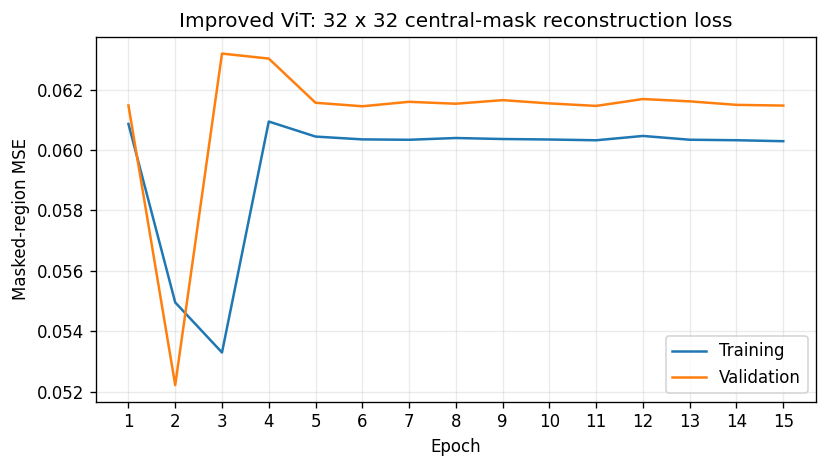

In [ ]:
epoch_numbers = range(1, len(improved_vit_train_losses) + 1)
fig, ax = plt.subplots(figsize=(7, 4), dpi=120)
ax.plot(epoch_numbers, improved_vit_train_losses, label='Training')
ax.plot(epoch_numbers, improved_vit_val_losses, label='Validation')
ax.set_title('Improved ViT: 32 x 32 central-mask reconstruction loss')
ax.set_xlabel('Epoch')
ax.set_ylabel('Masked-region MSE')
ax.set_xticks(list(epoch_numbers))
ax.legend()
ax.grid(alpha=0.25)
fig.tight_layout()
plt.show()

In [ ]:
improved_vit_validation_scores = {
    'Whole-image MSE': [],
    'Whole-image PSNR (dB)': [],
    'Whole-image SSIM': [],
    'Masked-region MSE': [],
    'Masked-region PSNR (dB)': [],
}
improved_vit_validation_examples = []
improved_vit.eval()
with torch.no_grad():
    for targets, _ in val_loader:
        targets = targets.to(DEVICE)
        masked_inputs, masks = make_training_inputs(targets)
        predictions = improved_vit(masked_inputs)
        reconstructions = reconstruct_images(masked_inputs, predictions, masks)

        assert reconstructions.shape == (targets.shape[0], 3, IMAGE_SIZE, IMAGE_SIZE)
        assert torch.isfinite(reconstructions).all().item()
        assert 0.0 <= reconstructions.min().item() <= reconstructions.max().item() <= 1.0
        visible_channels = (~masks).expand_as(targets)
        assert torch.equal(reconstructions[visible_channels], targets[visible_channels])

        for target, masked_input, reconstruction, mask in zip(
            targets, masked_inputs, reconstructions, masks
        ):
            for name, value in reconstruction_metrics(target, reconstruction, mask).items():
                improved_vit_validation_scores[name].append(value)

            if len(improved_vit_validation_examples) < 5:
                improved_vit_validation_examples.append((
                    target.cpu().clone(), masked_input.cpu().clone(), reconstruction.cpu().clone()
                ))

assert len(improved_vit_validation_scores['Whole-image MSE']) == len(val_loader.dataset)
improved_vit_validation_metrics = {
    name: float(np.mean(values)) for name, values in improved_vit_validation_scores.items()
}
# The restored model's masked MSE should match its best epoch's validation loss.
assert np.isclose(improved_vit_validation_metrics['Masked-region MSE'], best_improved_vit_val_loss, rtol=1e-4, atol=1e-7)
print(f'Improved ViT validation | best epoch {best_improved_vit_epoch} | 32 x 32 central masks')
for name, value in improved_vit_validation_metrics.items():
    print(f'{name}: {value:.6f}')
print('Reconstruction shape, range, and visible-pixel checks passed.')

assert len(improved_vit_validation_examples) == len(initial_vit_validation_examples)
for improved_example, initial_example in zip(improved_vit_validation_examples, initial_vit_validation_examples):
    assert torch.equal(improved_example[0], initial_example[0])
    assert torch.equal(improved_example[1], initial_example[1])
print('Initial and improved ViT examples use the same validation images and masks.')

Improved ViT validation | best epoch 2 | 32 x 32 central masks
Whole-image MSE: 0.003263
Whole-image PSNR (dB): 25.736396
Whole-image SSIM: 0.935920
Masked-region MSE: 0.052215
Masked-region PSNR (dB): 13.695196
Reconstruction shape, range, and visible-pixel checks passed.
Initial and improved ViT examples use the same validation images and masks.


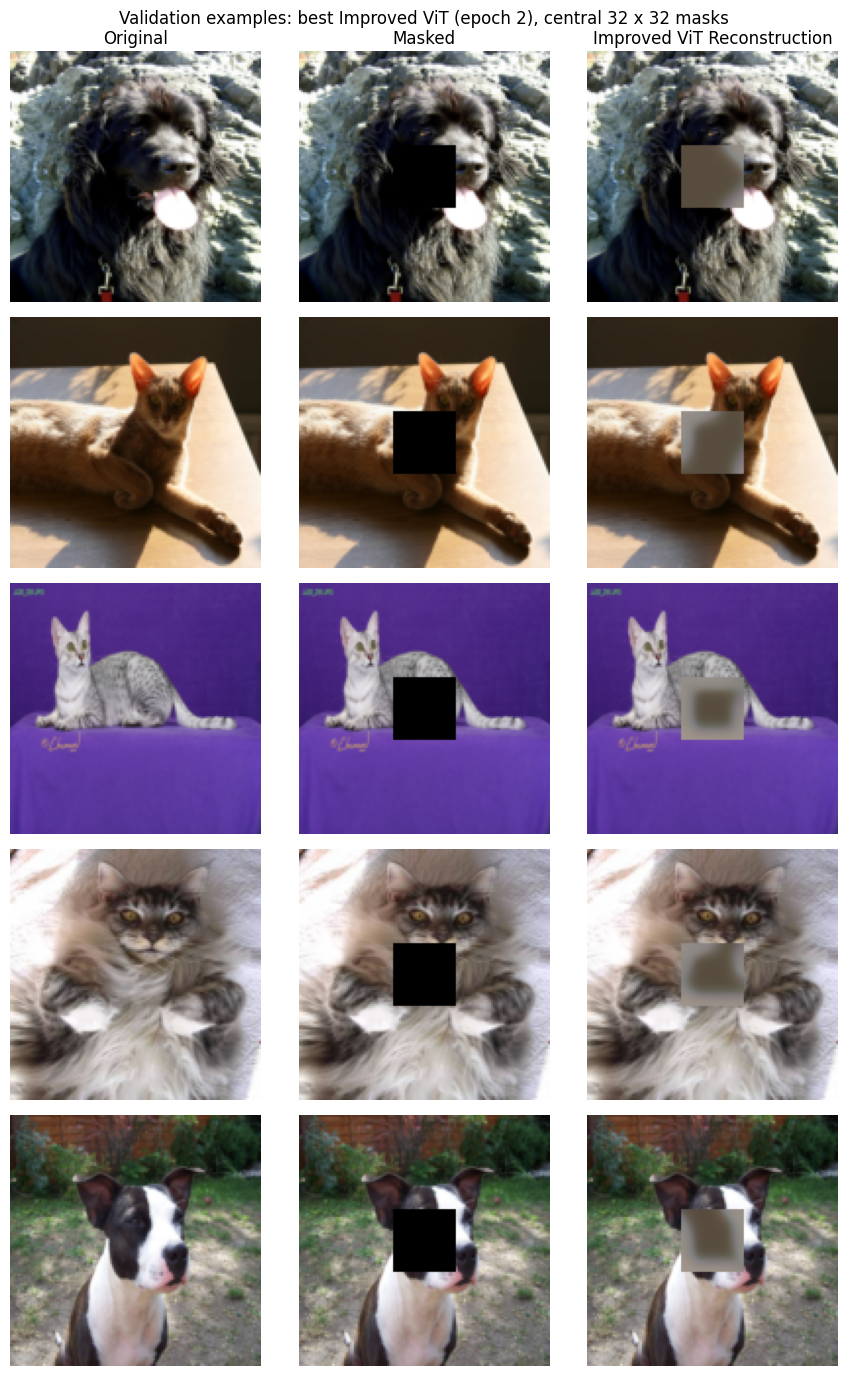

In [ ]:
fig, axes = plt.subplots(len(improved_vit_validation_examples), 3, figsize=(9, 14), squeeze=False)
for row, example in enumerate(improved_vit_validation_examples):
    for column, image in enumerate(example):
        axes[row, column].imshow(image.permute(1, 2, 0).numpy())
        axes[row, column].axis('off')
for ax, title in zip(axes[0], ('Original', 'Masked', 'Improved ViT Reconstruction')):
    ax.set_title(title)
fig.suptitle(f'Validation examples: best Improved ViT (epoch {best_improved_vit_epoch}), central 32 x 32 masks')
plt.tight_layout()
plt.show()

In [ ]:
# Read the existing initial results; do not retrain or reevaluate the initial ViT.
vit_improvement_comparison = pd.DataFrame.from_dict({
    'Initial ViT (16 x 16 patches)': initial_vit_validation_metrics,
    'Improved ViT (8 x 8 patches)': improved_vit_validation_metrics,
}, orient='index')
vit_improvement_comparison.index.name = 'Model'
print('Validation only: 32 x 32 central masks')
print(f'Initial best epoch: {initial_vit_best_epoch} | Improved best epoch: {best_improved_vit_epoch}')
display(vit_improvement_comparison.round(6))

Validation only: 32 x 32 central masks
Initial best epoch: 14 | Improved best epoch: 2


,Whole-image MSE,Whole-image PSNR (dB),Whole-image SSIM,Masked-region MSE,Masked-region PSNR (dB)
Model,,,,,
Initial ViT (16 x 16 patches),0.003780,25.020292,0.933219,0.060476,12.979092
Improved ViT (8 x 8 patches),0.003263,25.736396,0.935920,0.052215,13.695196


### Spatial Detail in Validation Reconstructions

The enlarged 32 x 32 missing regions compare the original target, initial ViT, and improved ViT on identical validation images. Edges, texture, and spatial variation provide a visual complement to the numerical metrics. Bilinear upsampling can smooth patch boundaries without recovering the true structure, so smoothness alone does not establish reconstruction quality.

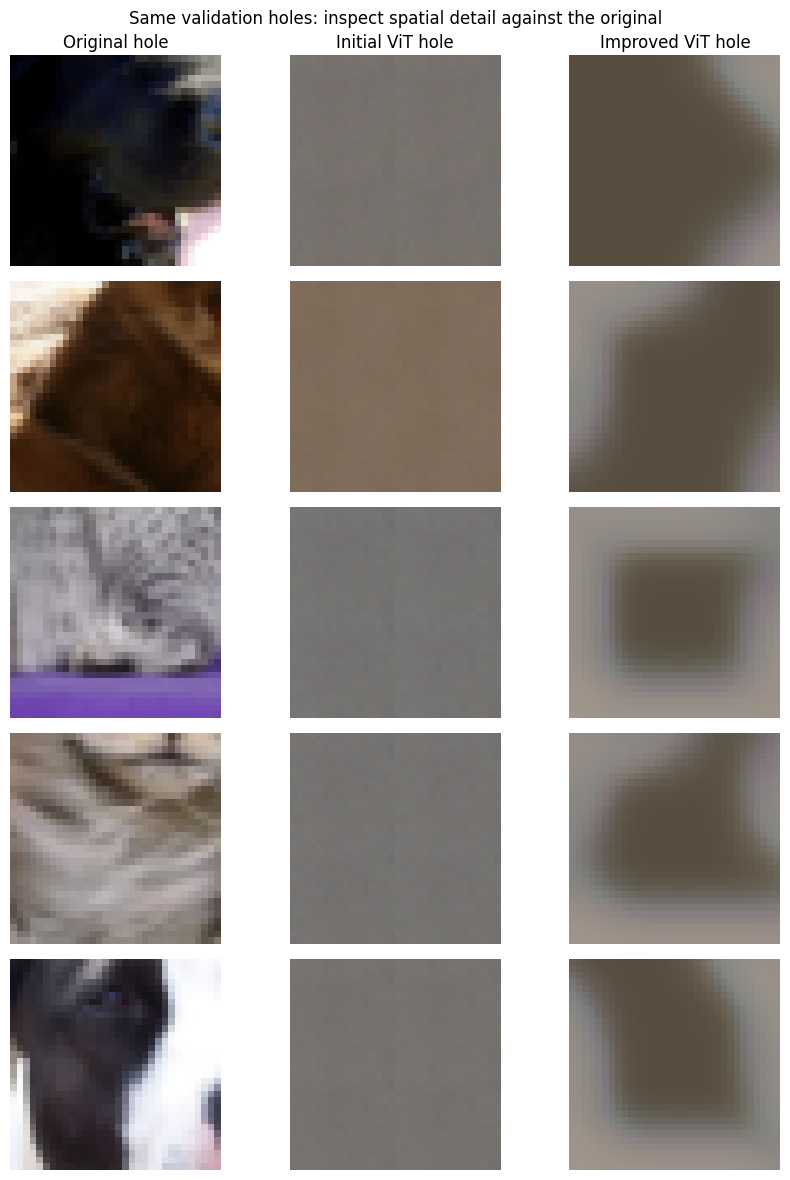

In [ ]:
hole_top = (IMAGE_SIZE - TRAIN_MASK_SIZE) // 2
hole_left = (IMAGE_SIZE - TRAIN_MASK_SIZE) // 2
fig, axes = plt.subplots(len(improved_vit_validation_examples), 3, figsize=(9, 12), squeeze=False)
for row, (initial_example, improved_example) in enumerate(zip(
    initial_vit_validation_examples, improved_vit_validation_examples
)):
    for column, image in enumerate((initial_example[0], initial_example[2], improved_example[2])):
        crop = image[:, hole_top:hole_top + TRAIN_MASK_SIZE, hole_left:hole_left + TRAIN_MASK_SIZE]
        axes[row, column].imshow(crop.permute(1, 2, 0).numpy(), interpolation='nearest')
        axes[row, column].axis('off')
for ax, title in zip(axes[0], ('Original hole', 'Initial ViT hole', 'Improved ViT hole')):
    ax.set_title(title)
fig.suptitle('Same validation holes: inspect spatial detail against the original')
plt.tight_layout()
plt.show()

### Initial and Improved ViT Validation Comparison

The 15-epoch AdamW run used learning rate 0.001, weight decay 0.01, batch size 32, and the existing train/validation splits with 32 x 32 central masks. The model has **684,963 trainable parameters** and **256 patch tokens**. The saved outputs document the completed experiment.

| Validation metric | Initial ViT | Improved ViT |
|---|---:|---:|
| Whole-image MSE | 0.003780 | 0.003263 |
| Whole-image PSNR (dB) | 25.020292 | 25.736396 |
| Whole-image SSIM | 0.933219 | 0.935920 |
| Masked-region MSE | 0.060476 | 0.052215 |
| Masked-region PSNR (dB) | 12.979092 | 13.695196 |
| Best epoch | 14 | 2 |

Masked-region MSE decreased by approximately **13.7%**. The improved model adds coarse spatial variation and smoother transitions compared with the initial nearly uniform predictions, but the five inspected holes remain blurry and do not reliably recover edges or fine texture. This is a modest improvement, not a resolution of the spatial-detail problem. Validation loss worsened after epoch 2 and stayed near 0.0615, and the lowest-loss checkpoint was restored. These validation results support the choice of the improved ViT; test data were not used for this choice.

## U-Net–ViT Ensemble

An ensemble can help when models make different reconstruction errors. RGB predictions are combined as `alpha * unet_prediction + (1 - alpha) * improved_vit_prediction`. The reconstruction helper inserts this average **only inside the missing region**, preserving all visible input pixels.

The **best-validation U-Net and improved ViT** are evaluated with frozen weights. Candidate alpha values **0.25, 0.50, and 0.75** represent 25%, 50%, and 75% U-Net contribution. All candidates use the same validation images, 32 x 32 central masks, and shared metric functions.

The candidate with the **lowest validation masked-region MSE** is selected and frozen for final test reporting. Validation-based selection keeps test data independent of model and ensemble choices. The five qualitative comparisons use identical validation originals and masks across approaches.

In [ ]:
ENSEMBLE_ALPHAS = (0.25, 0.50, 0.75)
assert IMAGE_SIZE == 128 and TRAIN_MASK_SIZE == 32

# Verify that the already-restored models are the saved best-validation models.
# These checks do not load or alter weights.
for name, parameter in unet.state_dict().items():
    assert torch.equal(parameter.detach().cpu(), best_unet_state[name].cpu()), 'U-Net is not at its best validation state.'
for name, parameter in improved_vit.state_dict().items():
    assert torch.equal(parameter.detach().cpu(), best_improved_vit_state[name].cpu()), 'Improved ViT is not at its best validation state.'
unet.eval()
improved_vit.eval()

print(f'U-Net best epoch: {best_unet_epoch} | Improved ViT best epoch: {best_improved_vit_epoch}')
print(f'Validation images: {len(val_loader.dataset)} | Central mask: {TRAIN_MASK_SIZE} x {TRAIN_MASK_SIZE}')
print(f'Alpha candidates (U-Net weight): {ENSEMBLE_ALPHAS}')

U-Net best epoch: 15 | Improved ViT best epoch: 2
Validation images: 736 | Central mask: 32 x 32
Alpha candidates (U-Net weight): (0.25, 0.5, 0.75)


In [ ]:
# Evaluate both individual models and all three weights in a single validation pass.
# Each model runs once per batch; only the small weighted average varies with alpha.
ensemble_labels = {alpha: f'Ensemble alpha = {alpha:.2f}' for alpha in ENSEMBLE_ALPHAS}
phase7_model_names = ['U-Net', 'Improved ViT', *ensemble_labels.values()]
phase7_scores = {
    model_name: {metric: [] for metric in unet_validation_metrics}
    for model_name in phase7_model_names
}
phase7_examples = []

with torch.no_grad():
    for targets, _ in val_loader:
        targets = targets.to(DEVICE)
        masked_inputs, masks = make_training_inputs(targets)
        unet_prediction = unet(masked_inputs)
        improved_vit_prediction = improved_vit(masked_inputs)
        phase7_predictions = {
            'U-Net': unet_prediction,
            'Improved ViT': improved_vit_prediction,
        }
        for alpha in ENSEMBLE_ALPHAS:
            phase7_predictions[ensemble_labels[alpha]] = (
                alpha * unet_prediction + (1 - alpha) * improved_vit_prediction
            )

        phase7_reconstructions = {}
        for model_name, prediction in phase7_predictions.items():
            reconstruction = reconstruct_images(masked_inputs, prediction, masks)
            assert reconstruction.shape == (targets.shape[0], 3, IMAGE_SIZE, IMAGE_SIZE)
            assert torch.isfinite(reconstruction).all().item()
            assert 0.0 <= reconstruction.min().item() <= reconstruction.max().item() <= 1.0
            visible_channels = (~masks).expand_as(targets)
            assert torch.equal(reconstruction[visible_channels], masked_inputs[visible_channels])
            phase7_reconstructions[model_name] = reconstruction
            for target, image, mask in zip(targets, reconstruction, masks):
                for metric, value in reconstruction_metrics(target, image, mask).items():
                    phase7_scores[model_name][metric].append(value)

        # Cache only the first five examples, including all three candidate ensembles.
        for index in range(min(targets.shape[0], 5 - len(phase7_examples))):
            phase7_examples.append({
                'Original': targets[index].cpu().clone(),
                'Masked': masked_inputs[index].cpu().clone(),
                **{name: batch[index].cpu().clone() for name, batch in phase7_reconstructions.items()},
            })

for scores in phase7_scores.values():
    assert all(len(values) == len(val_loader.dataset) for values in scores.values())
phase7_validation_metrics = {
    model_name: {metric: float(np.mean(values)) for metric, values in scores.items()}
    for model_name, scores in phase7_scores.items()
}

# Check that the individual-model results still agree with previous evaluations.
for model_name, stored_metrics in (
    ('U-Net', unet_validation_metrics), ('Improved ViT', improved_vit_validation_metrics)
):
    for metric, stored_value in stored_metrics.items():
        assert np.isclose(phase7_validation_metrics[model_name][metric], stored_value, rtol=1e-4, atol=1e-7)
assert len(phase7_examples) == len(unet_validation_examples)
for example, earlier_example in zip(phase7_examples, unet_validation_examples):
    assert torch.equal(example['Original'], earlier_example[0])
    assert torch.equal(example['Masked'], earlier_example[1])
print('Validation complete: all five approaches evaluated; shapes, ranges, visible pixels, and matching examples verified.')

Validation complete: all five approaches evaluated; shapes, ranges, visible pixels, and matching examples verified.


In [ ]:
# Select using full-precision mean masked-region MSE, not rounded table values.
SELECTED_ENSEMBLE_ALPHA = min(
    ENSEMBLE_ALPHAS,
    key=lambda alpha: phase7_validation_metrics[ensemble_labels[alpha]]['Masked-region MSE'],
)
selected_ensemble_label = ensemble_labels[SELECTED_ENSEMBLE_ALPHA]
selected_ensemble_metrics = dict(phase7_validation_metrics[selected_ensemble_label])

ensemble_validation_comparison = pd.DataFrame.from_dict(phase7_validation_metrics, orient='index')
ensemble_validation_comparison.index.name = 'Model'
ensemble_validation_comparison['Selected ensemble'] = [
    'Yes' if name == selected_ensemble_label else '' for name in ensemble_validation_comparison.index
]
print(f'SELECTED_ENSEMBLE_ALPHA = {SELECTED_ENSEMBLE_ALPHA:.2f}')
print(f'{SELECTED_ENSEMBLE_ALPHA:.0%} U-Net + {1 - SELECTED_ENSEMBLE_ALPHA:.0%} improved ViT')
print('Record this alpha for later frozen test evaluation; no test data used here.')
display(ensemble_validation_comparison.round(6))

for individual_name in ('U-Net', 'Improved ViT'):
    difference = selected_ensemble_metrics['Masked-region MSE'] - phase7_validation_metrics[individual_name]['Masked-region MSE']
    outcome = 'lower (better)' if difference < 0 else 'higher (worse)' if difference > 0 else 'equal'
    print(f'Selected ensemble masked MSE vs {individual_name}: {outcome}; difference = {difference:+.6f}')

SELECTED_ENSEMBLE_ALPHA = 0.75
75% U-Net + 25% improved ViT
Validation selection only; keep this alpha fixed for later test evaluation.


,Whole-image MSE,Whole-image PSNR (dB),Whole-image SSIM,Masked-region MSE,Masked-region PSNR (dB),Selected ensemble
Model,,,,,,
U-Net,0.001341,29.790144,0.957640,0.021456,17.748944,
Improved ViT,0.003263,25.736396,0.935920,0.052215,13.695196,
Ensemble alpha = 0.25,0.002426,26.974214,0.942055,0.038823,14.933014,
Ensemble alpha = 0.50,0.001827,28.186634,0.948331,0.029233,16.145434,
Ensemble alpha = 0.75,0.001465,29.221079,0.954066,0.023444,17.179879,Yes


Selected ensemble masked MSE vs U-Net: higher (worse); difference = +0.001988
Selected ensemble masked MSE vs Improved ViT: lower (better); difference = -0.028771


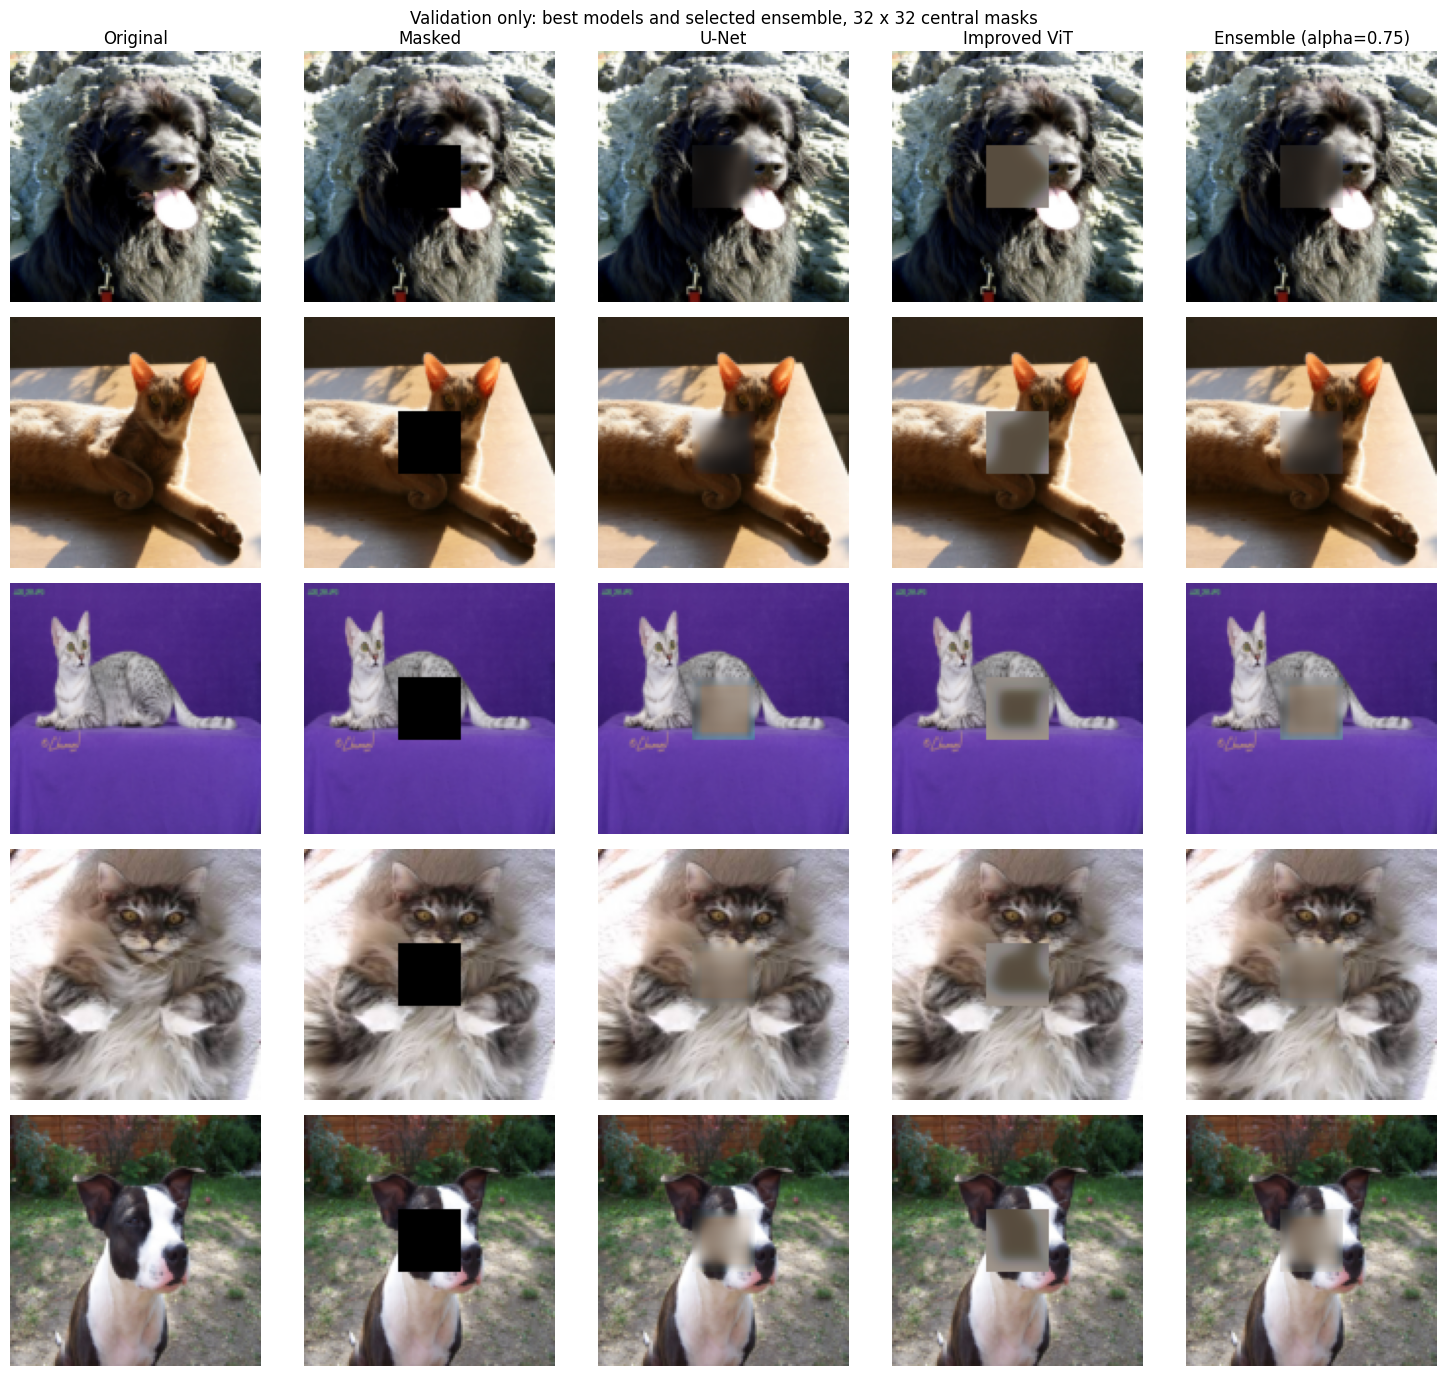

In [ ]:
phase7_columns = ['Original', 'Masked', 'U-Net', 'Improved ViT', selected_ensemble_label]
fig, axes = plt.subplots(len(phase7_examples), 5, figsize=(15, 14), squeeze=False)
for row, example in enumerate(phase7_examples):
    for column, name in enumerate(phase7_columns):
        axes[row, column].imshow(example[name].permute(1, 2, 0).numpy())
        axes[row, column].axis('off')
for ax, title in zip(axes[0], ('Original', 'Masked', 'U-Net', 'Improved ViT', f'Ensemble (alpha={SELECTED_ENSEMBLE_ALPHA:.2f})')):
    ax.set_title(title)
fig.suptitle('Validation only: best models and selected ensemble, 32 x 32 central masks')
plt.tight_layout()
plt.show()

### Ensemble Validation Results

The selected weight is **`SELECTED_ENSEMBLE_ALPHA = 0.75`**, meaning **75% U-Net + 25% improved ViT**. Selection used the lowest full-precision validation masked-region MSE among the three candidate weights on all 736 validation images. This alpha was frozen for final test evaluation.

| Model | MSE | PSNR (dB) | SSIM | Masked MSE | Masked PSNR (dB) |
|---|---:|---:|---:|---:|---:|
| U-Net | 0.001341 | 29.790144 | 0.957640 | 0.021456 | 17.748944 |
| Improved ViT | 0.003263 | 25.736396 | 0.935920 | 0.052215 | 13.695196 |
| Ensemble alpha = 0.25 | 0.002426 | 26.974214 | 0.942055 | 0.038823 | 14.933014 |
| Ensemble alpha = 0.50 | 0.001827 | 28.186634 | 0.948331 | 0.029233 | 16.145434 |
| **Ensemble alpha = 0.75 (selected)** | **0.001465** | **29.221079** | **0.954066** | **0.023444** | **17.179879** |

The selected ensemble improves on improved ViT but **does not improve on U-Net**: masked MSE is 0.023444 versus 0.021456 (approximately 9.3% higher). None of the three ensemble weights outperformed U-Net on validation masked MSE. The figure shows the ensemble remains close to U-Net with some smoothing from the ViT; it does not recover fine detail reliably. This is a validation observation, not the final test comparison.

Both models matched their saved best-validation weights before evaluation (U-Net epoch 15; improved ViT epoch 2). Reconstruction checks confirmed unchanged visible pixels and matching validation examples; validation evaluation did not update either model.

## Final Test Evaluation

Architectures and checkpoints were selected using training/validation data; ensemble alpha was selected using validation masked-region MSE. **The frozen choices are:** best-validation U-Net, best-validation improved ViT, and **alpha = 0.75** (75% U-Net). The official Oxford-IIIT Pet test split is used only for final reporting. Test results were not used to modify any model, checkpoint, learning rate, training procedure, or ensemble weight.

Both models were trained on 32 x 32 central masks. Final evaluation covers 24 x 24, 32 x 32, and 48 x 48 masks at central and random positions, without separate training. These six conditions measure robustness/generalization; the 32 x 32 central condition matches training.

Random masks use `SEED + sample_index + mask_size * len(test_dataset)`. The sample index is the fixed official-test order, independent of batch size. Each condition uses one masked input shared by all models; the ensemble averages predictions with the frozen alpha. Visible pixels are copied unchanged. Metrics reuse the validation implementation, including per-image averaging, RGB channel conventions, and data range 1.0.

Illustrative images were chosen before seeing scores (one fixed index per condition). Failure cases are the **three distinct test images with highest ensemble masked-region MSE across all conditions**, retaining each image's worst condition. This criterion is descriptive only and is not used for model selection.

In [ ]:
from torch.utils.data import SequentialSampler

FROZEN_ENSEMBLE_ALPHA = 0.75  # Explicitly freeze Phase 7's validation-selected value.
assert SELECTED_ENSEMBLE_ALPHA == FROZEN_ENSEMBLE_ALPHA
TEST_CONDITIONS = [
    ('central', 24), ('central', 32), ('central', 48),
    ('random', 24), ('random', 32), ('random', 48),
]
FINAL_MODEL_NAMES = ('U-Net', 'Improved ViT', 'Ensemble')
assert IMAGE_SIZE == 128
assert test_loader.dataset is test_dataset
assert isinstance(test_loader.sampler, SequentialSampler), 'Test order must be fixed.'
assert not test_loader.drop_last
for name, parameter in unet.state_dict().items():
    assert torch.equal(parameter.detach().cpu(), best_unet_state[name].cpu())
for name, parameter in improved_vit.state_dict().items():
    assert torch.equal(parameter.detach().cpu(), best_improved_vit_state[name].cpu())
unet.eval()
improved_vit.eval()
print(f'Frozen alpha: {FROZEN_ENSEMBLE_ALPHA:.2f}')
print(f'Frozen best epochs: U-Net={best_unet_epoch}, improved ViT={best_improved_vit_epoch}')
print(f'Official test images per condition: {len(test_dataset)}; conditions: {len(TEST_CONDITIONS)}')

Frozen alpha: 0.75
Frozen best epochs: U-Net=15, improved ViT=2
Official test images per condition: 3669; conditions: 6


In [ ]:
def make_test_inputs(targets, first_sample_index, mask_size, position):
    """Reuse Phase 2 masks, with per-image seeds independent of batching."""
    masks = torch.stack([
        make_rectangular_mask(
            target, (mask_size, mask_size), position=position,
            seed=SEED + first_sample_index + offset + mask_size * len(test_dataset),
        )
        for offset, target in enumerate(targets)
    ])
    return apply_mask(targets, masks), masks


def cache_test_example(targets, masked_inputs, reconstructions, index, sample_index, position, mask_size, score):
    """Keep only a few CPU images for report figures, not the entire test set."""
    return {
        'sample_index': sample_index, 'position': position, 'mask_size': mask_size,
        'ensemble_masked_mse': score,
        'images': {
            'Original': targets[index].clone(), 'Masked': masked_inputs[index].clone(),
            **{name: batch[index].clone() for name, batch in reconstructions.items()},
        },
    }


# Verify seed reproducibility and independence from batch boundaries without test inference.
mask_check_images = torch.zeros(2, 3, IMAGE_SIZE, IMAGE_SIZE)
for size in (24, 32, 48):
    _, together = make_test_inputs(mask_check_images, 10, size, 'random')
    _, repeated = make_test_inputs(mask_check_images, 10, size, 'random')
    _, separate = make_test_inputs(mask_check_images[1:], 11, size, 'random')
    assert torch.equal(together, repeated)
    assert torch.equal(together[1:], separate)
    assert together.shape == (2, 1, IMAGE_SIZE, IMAGE_SIZE)
    assert torch.all(together.sum(dim=(1, 2, 3)) == size * size).item()
print('Random masks are reproducible and independent of batch boundaries.')

Random masks are reproducible and independent of batch boundaries.


In [ ]:
final_test_rows = []
representative_test_examples = []
failure_test_examples = {}  # At most three distinct image indices.

with torch.no_grad():
    for condition_index, (position, size) in enumerate(TEST_CONDITIONS):
        condition_scores = {
            model_name: {metric: [] for metric in unet_validation_metrics}
            for model_name in FINAL_MODEL_NAMES
        }
        sample_offset = 0
        for batch_index, (targets_cpu, _) in enumerate(test_loader):
            # Build one CPU mask per image, then share the exact same input on DEVICE.
            masked_cpu, masks_cpu = make_test_inputs(targets_cpu, sample_offset, size, position)
            masked_inputs = masked_cpu.to(DEVICE)
            masks = masks_cpu.to(DEVICE)
            unet_prediction = unet(masked_inputs)
            vit_prediction = improved_vit(masked_inputs)
            predictions = {
                'U-Net': unet_prediction,
                'Improved ViT': vit_prediction,
                'Ensemble': FROZEN_ENSEMBLE_ALPHA * unet_prediction + (1 - FROZEN_ENSEMBLE_ALPHA) * vit_prediction,
            }
            reconstructions_cpu = {}
            for model_name, prediction in predictions.items():
                reconstruction = reconstruct_images(masked_inputs, prediction, masks)
                assert reconstruction.shape == (targets_cpu.shape[0], 3, IMAGE_SIZE, IMAGE_SIZE)
                assert torch.isfinite(reconstruction).all().item()
                assert 0.0 <= reconstruction.min().item() <= reconstruction.max().item() <= 1.0
                reconstruction_cpu = reconstruction.cpu()
                visible = (~masks_cpu).expand_as(targets_cpu)
                assert torch.equal(reconstruction_cpu[visible], targets_cpu[visible])
                reconstructions_cpu[model_name] = reconstruction_cpu

            for index, (target, mask) in enumerate(zip(targets_cpu, masks_cpu)):
                image_scores = {}
                for model_name in FINAL_MODEL_NAMES:
                    image_scores[model_name] = reconstruction_metrics(target, reconstructions_cpu[model_name][index], mask)
                    for metric, value in image_scores[model_name].items():
                        condition_scores[model_name][metric].append(value)
                sample_index = sample_offset + index
                failure_score = image_scores['Ensemble']['Masked-region MSE']
                # Six fixed examples: indices 0 through 5, one for each condition.
                if sample_index == condition_index:
                    representative_test_examples.append(cache_test_example(
                        targets_cpu, masked_cpu, reconstructions_cpu, index, sample_index, position, size, failure_score
                    ))
                # Highest-error distinct images, retaining the worst condition for each.
                if sample_index in failure_test_examples:
                    keep_failure = failure_score > failure_test_examples[sample_index]['ensemble_masked_mse']
                else:
                    keep_failure = len(failure_test_examples) < 3 or failure_score > min(
                        example['ensemble_masked_mse'] for example in failure_test_examples.values()
                    )
                if keep_failure:
                    failure_test_examples[sample_index] = cache_test_example(
                        targets_cpu, masked_cpu, reconstructions_cpu, index, sample_index, position, size, failure_score
                    )
                    if len(failure_test_examples) > 3:
                        lowest_index = min(failure_test_examples, key=lambda key: failure_test_examples[key]['ensemble_masked_mse'])
                        del failure_test_examples[lowest_index]
            sample_offset += targets_cpu.shape[0]
            if (batch_index + 1) % 32 == 0:
                print(f'{position} {size} x {size}: {sample_offset}/{len(test_dataset)} images', flush=True)

        assert sample_offset == len(test_dataset)
        for model_name, scores in condition_scores.items():
            assert all(len(values) == len(test_dataset) for values in scores.values())
            final_test_rows.append({
                'Mask Type': position, 'Mask Size': size, 'Model': model_name,
                **{metric: float(np.mean(values)) for metric, values in scores.items()},
            })
        print(f'Completed {position} {size} x {size}: all {sample_offset} test images.', flush=True)

assert len(final_test_rows) == 18
assert len(representative_test_examples) == 6
assert SELECTED_ENSEMBLE_ALPHA == FROZEN_ENSEMBLE_ALPHA == 0.75
# Confirm inference did not change either model's saved best weights.
for name, parameter in unet.state_dict().items():
    assert torch.equal(parameter.detach().cpu(), best_unet_state[name].cpu())
for name, parameter in improved_vit.state_dict().items():
    assert torch.equal(parameter.detach().cpu(), best_improved_vit_state[name].cpu())
print('Final test evaluation complete. Frozen weights/alpha and reconstruction checks passed.')

central 24 x 24: 1024/3669 images
central 24 x 24: 2048/3669 images
central 24 x 24: 3072/3669 images
Completed central 24 x 24: all 3669 test images.
central 32 x 32: 1024/3669 images
central 32 x 32: 2048/3669 images
central 32 x 32: 3072/3669 images
Completed central 32 x 32: all 3669 test images.
central 48 x 48: 1024/3669 images
central 48 x 48: 2048/3669 images
central 48 x 48: 3072/3669 images
Completed central 48 x 48: all 3669 test images.
random 24 x 24: 1024/3669 images
random 24 x 24: 2048/3669 images
random 24 x 24: 3072/3669 images
Completed random 24 x 24: all 3669 test images.
random 32 x 32: 1024/3669 images
random 32 x 32: 2048/3669 images
random 32 x 32: 3072/3669 images
Completed random 32 x 32: all 3669 test images.
random 48 x 48: 1024/3669 images
random 48 x 48: 2048/3669 images
random 48 x 48: 3072/3669 images
Completed random 48 x 48: all 3669 test images.
Final test evaluation complete. Frozen weights/alpha and reconstruction checks passed.


In [ ]:
final_test_results = pd.DataFrame(final_test_rows).rename(columns={
    'Whole-image MSE': 'MSE', 'Whole-image PSNR (dB)': 'PSNR (dB)', 'Whole-image SSIM': 'SSIM',
    'Masked-region MSE': 'Masked MSE', 'Masked-region PSNR (dB)': 'Masked PSNR (dB)',
})
print(f'FINAL TEST RESULTS: {len(test_dataset)} images per condition; ensemble alpha fixed at {FROZEN_ENSEMBLE_ALPHA:.2f}')
display(final_test_results.round(6))

FINAL TEST RESULTS: 3669 images per condition; ensemble alpha fixed at 0.75


,Mask Type,Mask Size,Model,MSE,PSNR (dB),SSIM,Masked MSE,Masked PSNR (dB)
0,central,24,U-Net,0.000662,33.211426,0.977649,0.018838,18.671452
1,central,24,Improved ViT,0.001929,28.163791,0.962271,0.054867,13.623816
2,central,24,Ensemble,0.000730,32.372011,0.975049,0.020754,17.832036
3,central,32,U-Net,0.001419,29.609073,0.957453,0.022701,17.567873
4,central,32,Improved ViT,0.003354,25.552664,0.935390,0.053672,13.511464
5,central,32,Ensemble,0.001540,29.004844,0.953816,0.024647,16.963645
6,central,48,U-Net,0.008780,21.540174,0.885556,0.062435,13.020799
7,central,48,Improved ViT,0.008699,21.267284,0.857928,0.061863,12.747910
8,central,48,Ensemble,0.008085,21.906030,0.881179,0.057497,13.386655
9,random,24,U-Net,0.000883,32.188362,0.974615,0.025102,17.648387


## Effect of Mask Size and Position

The following plot compares test masked-region MSE across the three mask sizes, with central and random positions shown separately. The accompanying table reports random-minus-central differences: a positive value indicates greater reconstruction error for random masks. Both analyses use the same frozen models and ensemble weight.

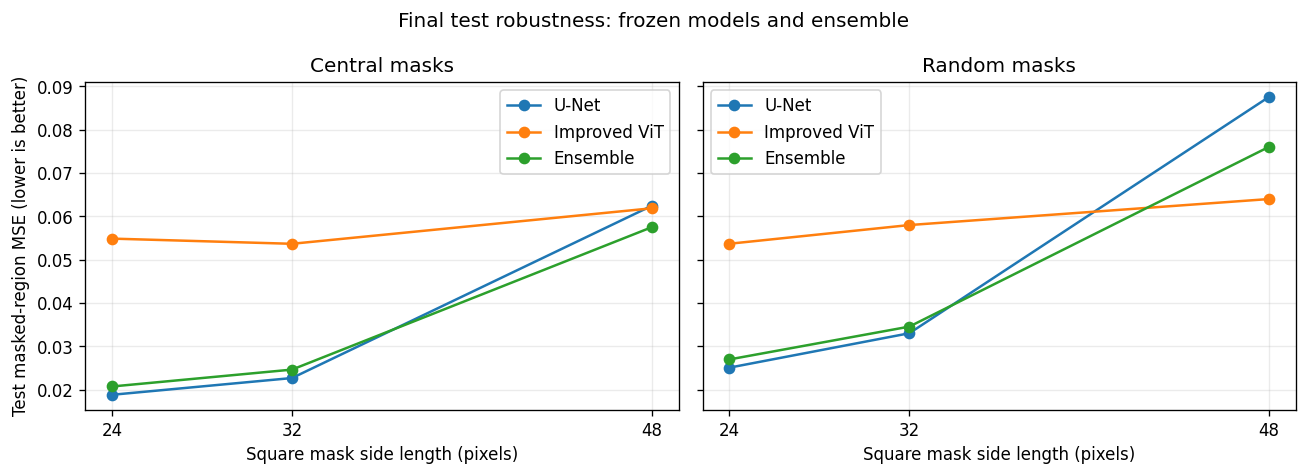

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4), dpi=120, sharey=True)
for ax, position in zip(axes, ('central', 'random')):
    for model_name in FINAL_MODEL_NAMES:
        subset = final_test_results[
            (final_test_results['Mask Type'] == position) & (final_test_results['Model'] == model_name)
        ].sort_values('Mask Size')
        ax.plot(subset['Mask Size'], subset['Masked MSE'], marker='o', label=model_name)
    ax.set_title(f'{position.capitalize()} masks')
    ax.set_xlabel('Square mask side length (pixels)')
    ax.set_xticks([24, 32, 48])
    ax.grid(alpha=0.25)
    ax.legend()
axes[0].set_ylabel('Test masked-region MSE (lower is better)')
fig.suptitle('Final test robustness: frozen models and ensemble')
fig.tight_layout()
plt.show()

In [ ]:
# One compact position comparison using the same primary metric as the plot.
test_position_comparison = final_test_results.pivot(
    index=['Mask Size', 'Model'], columns='Mask Type', values='Masked MSE'
).reindex(columns=['central', 'random'])
test_position_comparison['Random minus central'] = test_position_comparison['random'] - test_position_comparison['central']
print('Test masked MSE: positive difference means random masks are harder on average.')
display(test_position_comparison.round(6))

Test masked MSE: positive difference means random masks are harder on average.


Mask Type	central	random	Random minus central
Mask Size	Model			
24	Ensemble	0.020754	0.026997	0.006243
Improved ViT	0.054867	0.053685	-0.001182
U-Net	0.018838	0.025102	0.006264
32	Ensemble	0.024647	0.034565	0.009918
Improved ViT	0.053672	0.057996	0.004324
U-Net	0.022701	0.033036	0.010335
48	Ensemble	0.057497	0.076040	0.018543
Improved ViT	0.061863	0.063999	0.002136
U-Net	0.062435	0.087565	0.025129

## Qualitative Results

Six fixed test examples illustrate the six mask conditions using **Original | Masked | U-Net | Improved ViT | Ensemble**. Image indices were chosen before viewing scores, one per condition. These examples support visual interpretation of the metrics but do not estimate the frequency of particular successes or failures.

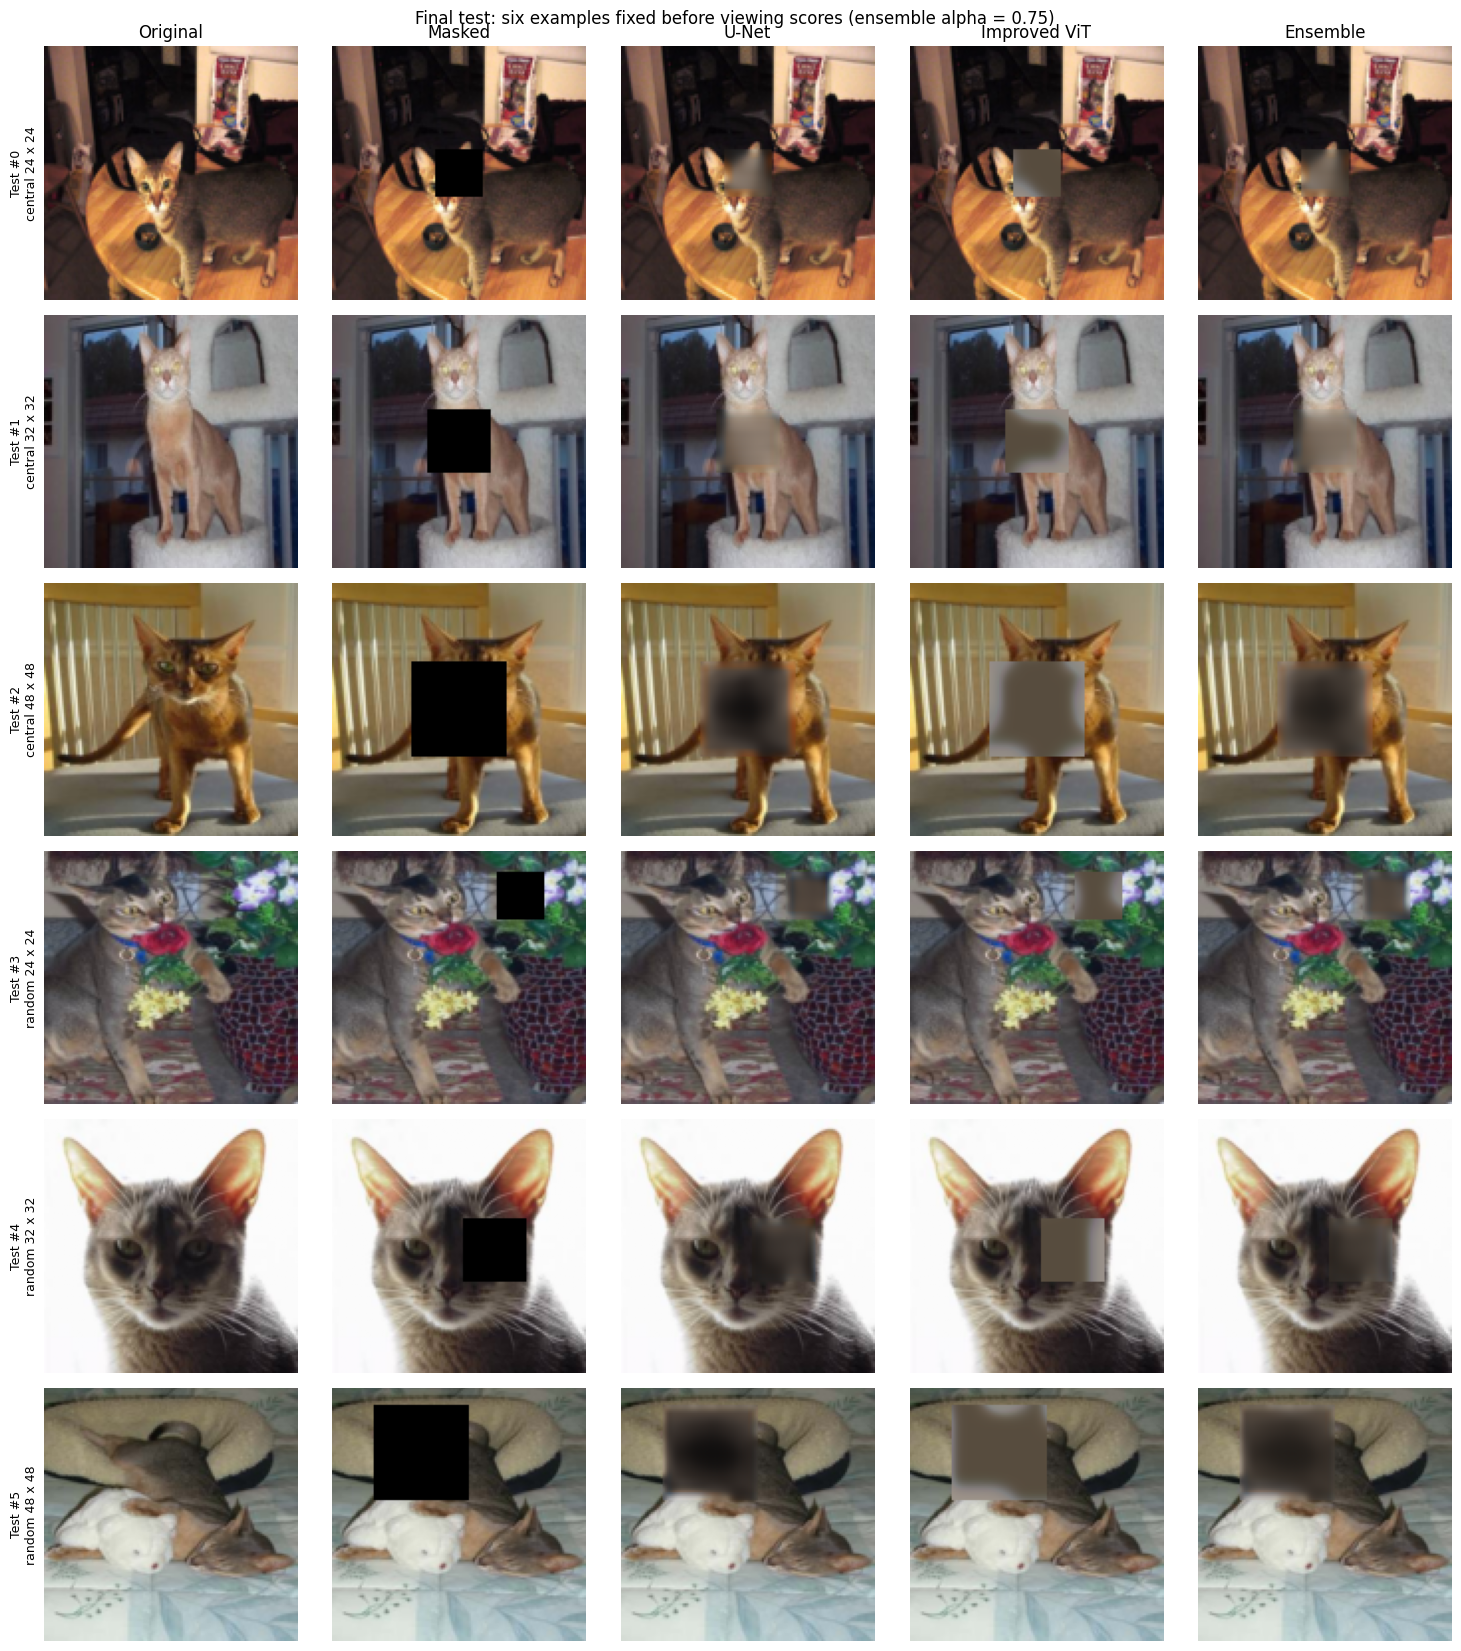

In [ ]:
def show_test_examples(examples, title):
    """Shared five-column layout for representative and difficult test images."""
    columns = ('Original', 'Masked', 'U-Net', 'Improved ViT', 'Ensemble')
    fig, axes = plt.subplots(len(examples), 5, figsize=(15, 2.8 * len(examples)), squeeze=False)
    for row, example in enumerate(examples):
        for column, name in enumerate(columns):
            ax = axes[row, column]
            ax.imshow(example['images'][name].permute(1, 2, 0).numpy())
            ax.set_xticks([])
            ax.set_yticks([])
            for spine in ax.spines.values():
                spine.set_visible(False)
        axes[row, 0].set_ylabel(
            f"Test #{example['sample_index']}\n{example['position']} {example['mask_size']} x {example['mask_size']}",
            fontsize=9,
        )
    for ax, column in zip(axes[0], columns):
        ax.set_title(column)
    fig.suptitle(title)
    fig.tight_layout()
    plt.show()


show_test_examples(representative_test_examples, 'Final test: six examples fixed before viewing scores (ensemble alpha = 0.75)')

## Failure Analysis

Difficult cases are selected by the highest ensemble masked-region MSE across all six conditions. The three distinct test images are retained with each image's worst condition. This descriptive analysis does not influence checkpoints, architecture, or ensemble weight.

Difficult cases: highest ensemble masked MSE across all six conditions; three distinct images.


,Test index,Mask Type,Mask Size,Ensemble masked MSE
0,1121,random,48,0.379974
1,2441,random,48,0.364197
2,1889,random,48,0.358225


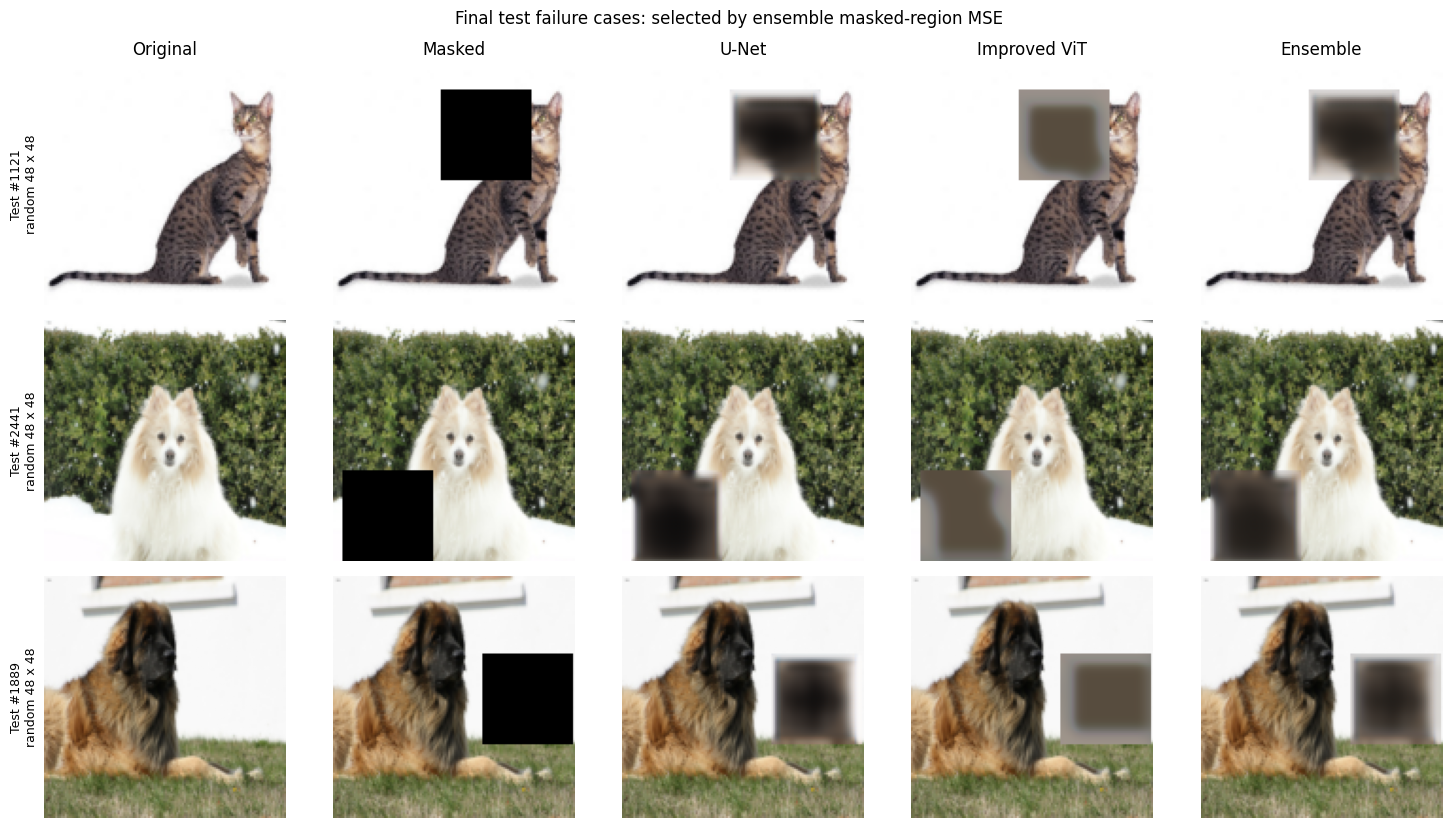

In [ ]:
worst_test_examples = sorted(failure_test_examples.values(), key=lambda example: example['ensemble_masked_mse'], reverse=True)
failure_case_table = pd.DataFrame([
    {'Test index': example['sample_index'], 'Mask Type': example['position'],
     'Mask Size': example['mask_size'], 'Ensemble masked MSE': example['ensemble_masked_mse']}
    for example in worst_test_examples
])
print('Difficult cases: highest ensemble masked MSE across all six conditions; three distinct images.')
display(failure_case_table.round(6))
show_test_examples(worst_test_examples, 'Final test failure cases: selected by ensemble masked-region MSE')

### Observed test failure cases

The three highest-error distinct images for the frozen ensemble are test indices **1121, 2441, and 1889**, all with **random 48 x 48 masks**. Their masked-region MSE values are **0.379974, 0.364197, and 0.358225**, respectively. These are difficult examples selected by the stated error criterion, not a representative sample of all failures.

In these images, much of the missing content is a bright background: the white area next to the cat, the bright ground beside the light-colored dog, and the white wall beside the brown dog. U-Net fills these regions with dark, blurred patches; the improved ViT produces flatter brown/gray patches. The ensemble retains a substantial brightness mismatch and cannot restore the missing background boundaries. Large holes can therefore fail even when they cover relatively simple backgrounds rather than an entire animal face.

The six fixed illustrative examples also show blurred fur/body boundaries, missing eye detail, and lost foliage detail. The improved ViT's fills remain especially smooth, and averaging does not recover fine texture. These visual observations describe the displayed images; they do not establish how common each failure type is.

## Discussion

These results use **3,669 official test images per condition**, the best-validation U-Net (epoch 15), the best-validation improved ViT (epoch 2), and the validation-selected **alpha = 0.75**. All six conditions were evaluated without retraining or changing model choices. Assertions confirmed unchanged model weights, reproducible masks, valid output shapes/ranges, and unchanged visible pixels.

- **U-Net:** lowest masked-region MSE, and best reported metrics, for both central and random 24 x 24 and 32 x 32 masks. Its central masked MSE rises from **0.018838 to 0.022701 to 0.062435** as size increases; random-mask values are **0.025102, 0.033036, and 0.087565**.
- **Improved ViT:** weaker small-hole results, but a smaller change across mask sizes. Central masked MSE is **0.054867, 0.053672, and 0.061863**, so it is not strictly increasing. Random values are **0.053685, 0.057996, and 0.063999**. It has the lowest MSE and highest PSNR for random 48 x 48 masks, while U-Net still has higher SSIM in that condition.
- **Ensemble:** improves masked MSE over both models for central 48 x 48 masks (**0.057497**, versus **0.062435** U-Net and **0.061863** ViT). It also has the best PSNR there, but U-Net has higher SSIM. For 24 x 24 and 32 x 32 masks it improves over ViT but not U-Net. For random 48 x 48 it improves over U-Net but not ViT (**0.076040** masked MSE). There is no universal ensemble advantage.
- **Position:** random masks increase masked MSE for U-Net and the ensemble at every size. ViT changes less: random minus central is **-0.001182, +0.004324, and +0.002136** at sizes 24, 32, and 48. These are results for this deterministic set of random positions; no significance test or claim about every possible mask placement is made.

Whole-image metrics include unchanged visible pixels, so masked-region MSE/PSNR and reconstruction examples are important for interpreting inpainting quality. PSNR is averaged per image using the existing validation convention; it is not computed from the final mean MSE.

In the displayed reconstructions, U-Net provides more local spatial variation, while the improved ViT produces smoother, flatter fills. Both lose fine texture and some object boundaries. Averaging can reduce numerical error, as in central 48 x 48 masks, without restoring missing semantic detail. The measured benefit therefore depends on the mask condition and metric rather than indicating a universally superior approach.

## Conclusion and Limitations

This study compared U-Net, an initial and revised lightweight ViT, and a weighted U-Net–ViT ensemble for image inpainting. The revised ViT improved all recorded validation metrics over the initial model, but its reconstructions remained smooth and lacked fine detail.

On the final test set, U-Net achieved the best reported metrics for 24 x 24 and 32 x 32 masks at both positions. The frozen ensemble reduced masked-region MSE below both individual models for central 48 x 48 masks. Improved ViT achieved the lowest MSE and highest PSNR for random 48 x 48 masks, while U-Net retained higher SSIM. The ensemble's benefit is therefore conditional, and no approach is uniformly best.

The scope of these conclusions is limited by:

- Training used only **32 x 32 central masks**. Other sizes and random positions were evaluated without retraining.
- Only **Oxford-IIIT Pet** images resized to **128 x 128** were studied.
- Random-mask evaluation used one deterministic realization per test image and size; it does not characterize every possible placement.
- The ViT revision changed both patch/decoder design and optimizer, so the validation improvement cannot be attributed to architecture alone.
- Large or visually complex missing regions remain difficult. The saved examples show blurred texture, missing facial detail, and brightness errors even in simple backgrounds.
- Whole-image metrics include unchanged visible pixels; masked-region metrics and qualitative inspection are needed to interpret reconstruction quality.

All reported findings use the existing validation-selected checkpoints and frozen ensemble alpha. Test results describe the completed experiment and were not used for further model selection.